In [1]:
!pip install arch
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.4 MB/s eta 0:00:00


In [2]:
# IMPORTS & DRIVE MOUNT
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import warnings
from scipy.stats import skew, kurtosis
import seaborn as sns
from pathlib import Path
from scipy.stats import t, norm
import statsmodels.api as sm
import networkx as nx
from itertools import combinations
import xgboost as xgb
from numpy.linalg import LinAlgError
import numba as nb
from typing import Dict
import inspect
import math, inspect, warnings
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pickle
from typing import Tuple
from joblib import Parallel, delayed
from arch import arch_model
from scipy.stats import mstats
from scipy.special import gamma as _gamma
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from numba import njit
import itertools
from pathlib import Path
from google.colab import drive
from numpy.lib.stride_tricks import sliding_window_view
import builtins
import numba as nb

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# VARIABLES (DATA LOADING & SETUP)

# Create a shortcut to the file on MyDrive to run the code below
daily = pd.read_csv('/content/drive/MyDrive/Multi-Alpha_Trading_Strategy_Project/stock_data/USDaily.csv')

In [4]:
# Notebook-style previews
display(daily.head())
len(daily.ticker.unique())

# Imports the data for further use
dividends = pd.read_csv('/content/drive/MyDrive/Multi-Alpha_Trading_Strategy_Project/stock_data/USDividend.csv')
us_split = pd.read_csv('/content/drive/MyDrive/Multi-Alpha_Trading_Strategy_Project/stock_data/USSplit.csv')
gics_class = pd.read_excel('/content/drive/MyDrive/Multi-Alpha_Trading_Strategy_Project/bloomberg_data/GICS_Classification.xlsx')
print(gics_class)

,ticker,date,open,high,low,close,volume,vwap,n_trades
0,A,2023-09-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,2023-09-05,121.64,122.5365,118.67,118.73,1270623.0,119.3014,24544.0
2,A,2023-09-06,118.35,118.6600,116.53,117.94,1668904.0,117.6159,32590.0
3,A,2023-09-07,117.97,118.0100,116.09,116.26,1316994.0,116.4744,26374.0
4,A,2023-09-08,116.01,116.2100,113.71,113.99,1789767.0,114.3638,35212.0


     ticker     Equity    Ticker+Equity  GICS_SECTOR  \
0         A  US Equity      A US Equity  Health Care   
1        AA  US Equity     AA US Equity    Materials   
2      AACB  US Equity   AACB US Equity          NaN   
3     AACBR  US Equity  AACBR US Equity          NaN   
4     AACBU  US Equity  AACBU US Equity          NaN   
...     ...        ...              ...          ...   
7927    ZWS  US Equity    ZWS US Equity  Industrials   
7928   ZYBT  US Equity   ZYBT US Equity  Health Care   
7929   ZYME  US Equity   ZYME US Equity  Health Care   
7930   ZYXI  US Equity   ZYXI US Equity  Health Care   
7931    ZZZ  US Equity    ZZZ US Equity        Funds   

                       GICS_INDUSTRY                GICS_SUBINDUSTRY  
0     Life Sciences Tools & Services  Life Sciences Tools & Services  
1                    Metals & Mining                        Aluminum  
2                                NaN                             NaN  
3                                NaN       

In [5]:
count_sector = gics_class['GICS_SECTOR'].notnull().sum()
print("sector not null: ", count_sector)

count_industry = gics_class['GICS_INDUSTRY'].notnull().sum()
print("industry not null: ", count_industry)

count_subindustry = gics_class['GICS_SUBINDUSTRY'].notnull().sum()
print("subindustry not null: ", count_subindustry)

count_all = gics_class[gics_class[['GICS_SECTOR', 'GICS_INDUSTRY', 'GICS_SUBINDUSTRY']].notnull().all(axis=1)].shape[0]
print("sec, ind, subind not null: ", count_all)

sector not null:  6753
industry not null:  6753
subindustry not null:  6753
sec, ind, subind not null:  6753


In [6]:
# MATRICES: GICS CLASSIFICATION (SECTOR / INDUSTRY / SUBINDUSTRY)
# Sector Classification Matrix
ticker_sector = gics_class.drop_duplicates(subset=['ticker']).set_index('ticker')['GICS_SECTOR']
date = daily['date'].drop_duplicates().sort_values()
ticker = daily['ticker'].drop_duplicates().sort_values()
sector_matrix = pd.DataFrame(index=date, columns=ticker)
sector_matrix.loc[:, :] = ticker_sector.reindex(sector_matrix.columns).values
sector_matrix = sector_matrix.dropna(axis=1, how='all')
print(sector_matrix)

ticker                A         AA                    AACG   AADR  \
date                                                                
2023-09-04  Health Care  Materials  Consumer Discretionary  Funds   
2023-09-05  Health Care  Materials  Consumer Discretionary  Funds   
2023-09-06  Health Care  Materials  Consumer Discretionary  Funds   
2023-09-07  Health Care  Materials  Consumer Discretionary  Funds   
2023-09-08  Health Care  Materials  Consumer Discretionary  Funds   
...                 ...        ...                     ...    ...   
2025-08-27  Health Care  Materials  Consumer Discretionary  Funds   
2025-08-28  Health Care  Materials  Consumer Discretionary  Funds   
2025-08-29  Health Care  Materials  Consumer Discretionary  Funds   
2025-09-01  Health Care  Materials  Consumer Discretionary  Funds   
2025-09-02  Health Care  Materials  Consumer Discretionary  Funds   

ticker              AAL   AALG        AAME        AAMI  \
date                                        

In [7]:
# Industry Classification Matrix
ticker_industry = gics_class.drop_duplicates(subset=['ticker']).set_index('ticker')['GICS_INDUSTRY']
industry = pd.DataFrame(index=date, columns=ticker)
industry.loc[:, :] = ticker_industry.reindex(industry.columns).values
industry = industry.dropna(axis=1, how='all')
print(industry)


ticker                                   A               AA  \
date                                                          
2023-09-04  Life Sciences Tools & Services  Metals & Mining   
2023-09-05  Life Sciences Tools & Services  Metals & Mining   
2023-09-06  Life Sciences Tools & Services  Metals & Mining   
2023-09-07  Life Sciences Tools & Services  Metals & Mining   
2023-09-08  Life Sciences Tools & Services  Metals & Mining   
...                                    ...              ...   
2025-08-27  Life Sciences Tools & Services  Metals & Mining   
2025-08-28  Life Sciences Tools & Services  Metals & Mining   
2025-08-29  Life Sciences Tools & Services  Metals & Mining   
2025-09-01  Life Sciences Tools & Services  Metals & Mining   
2025-09-02  Life Sciences Tools & Services  Metals & Mining   

ticker                               AACG         AADR                 AAL  \
date                                                                         
2023-09-04  Diversified 

In [8]:

# SubIndustry Classification Matrix
ticker_subindustry = gics_class.drop_duplicates(subset=['ticker']).set_index('ticker')['GICS_SUBINDUSTRY']
subindustry = pd.DataFrame(index=date, columns=ticker)
subindustry.loc[:, :] = ticker_subindustry.reindex(subindustry.columns).values
subindustry = subindustry.dropna(axis=1, how='all')
print(subindustry)

ticker                                   A        AA                AACG  \
date                                                                       
2023-09-04  Life Sciences Tools & Services  Aluminum  Education Services   
2023-09-05  Life Sciences Tools & Services  Aluminum  Education Services   
2023-09-06  Life Sciences Tools & Services  Aluminum  Education Services   
2023-09-07  Life Sciences Tools & Services  Aluminum  Education Services   
2023-09-08  Life Sciences Tools & Services  Aluminum  Education Services   
...                                    ...       ...                 ...   
2025-08-27  Life Sciences Tools & Services  Aluminum  Education Services   
2025-08-28  Life Sciences Tools & Services  Aluminum  Education Services   
2025-08-29  Life Sciences Tools & Services  Aluminum  Education Services   
2025-09-01  Life Sciences Tools & Services  Aluminum  Education Services   
2025-09-02  Life Sciences Tools & Services  Aluminum  Education Services   

ticker     

In [9]:
# Keep only tickers that exist in the classification data
valid_tickers = sector_matrix.columns

# Filter daily data by those tickers
daily_filtered = daily[daily['ticker'].isin(valid_tickers)].copy()
dividends = dividends[dividends['ticker'].isin(valid_tickers)].copy()
us_split = us_split[us_split['ticker'].isin(valid_tickers)].copy()
# Sort cleanly
daily_filtered = daily_filtered.sort_values(['ticker','date']).reset_index(drop=True)

daily_filtered['ticker'].nunique()

6753

In [10]:
# MATRICES: DIVIDEND & SPLIT

div = dividends.pivot(
    index="date",
    columns="ticker",
    values="cash_amount"
)

split = us_split.pivot(
    index="date",
    columns="ticker",
    values="S"
)



In [11]:
us_split.dropna()

,ticker,date,F,S
45192,AHT,2024-10-28,0.100000,-0.900000
53786,AKA,2023-10-02,0.083333,-0.916667
66643,ALUR,2025-01-03,0.040000,-0.960000
79920,AMTD,2023-11-17,0.333333,-0.666667
81133,AMWL,2024-07-11,0.050000,-0.950000
...,...,...,...,...
4118271,YYAI,2024-06-27,0.050000,-0.950000
4120650,ZBAI,2025-08-08,0.055556,-0.944444
4122362,ZCMD,2024-02-29,0.100000,-0.900000
4129655,ZJYL,2024-02-08,20.000000,19.000000


In [12]:

# MATRICES: PRICE / VOLUME / VWAP / OHLC

# Construction of volume, amount, vwap matrices
volume = daily_filtered.pivot(index='date', columns='ticker', values='volume')
volume = volume.loc[:, volume.columns.notna()]

vwap = daily_filtered.pivot(index='date', columns='ticker', values='vwap')
vwap = vwap.loc[:, vwap.columns.notna()]

amount = daily_filtered.pivot(index='date', columns='ticker', values='n_trades')
amount = amount.loc[:, amount.columns.notna()]

# Construction of open_m, close, high, low matrices
open_m = daily_filtered.pivot(index='date', columns='ticker', values='open')
open_m = open_m.loc[:, ~pd.isna(open_m.columns)]

close = daily_filtered.pivot(index='date', columns='ticker', values='close')
close = close.loc[:, ~pd.isna(close.columns)]

high = daily_filtered.pivot(index='date', columns='ticker', values='high')
high = high.loc[:, ~pd.isna(high.columns)]

low = daily_filtered.pivot(index='date', columns='ticker', values='low')
low = low.loc[:, ~pd.isna(low.columns)]


In [13]:
def log(x: pd.DataFrame) -> pd.DataFrame:
    return np.log(x)

def sign(x: pd.DataFrame) -> pd.DataFrame:
    return np.sign(x)

def rank(x: pd.DataFrame) -> pd.DataFrame:
    return x.rank(axis=1, pct=True)

def delay(x: pd.DataFrame, d: float) -> pd.DataFrame:
    return x.shift(int(np.floor(d)))

def correlation(x: pd.DataFrame, y: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).corr(y)

def covariance(x: pd.DataFrame, y: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).cov(y)

def scale(x: pd.DataFrame, a: float = 1.0) -> pd.DataFrame:
    abs_sum = x.abs().sum(axis=1).replace(0, np.nan)
    return x.mul(a, axis=0).div(abs_sum, axis=0)

def delta(x: pd.DataFrame, d: float) -> pd.DataFrame:
    return x - x.shift(int(np.floor(d)))

def signedpower(x: pd.DataFrame, a: float) -> pd.DataFrame:
    return np.sign(x) * (x.abs() ** a)

def decay_linear(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    weights = np.arange(w, 0, -1, dtype=float)
    norm = weights.sum()
    def _lw(arr: np.ndarray) -> float:
        return float((weights * arr).sum() / norm)
    return x.rolling(window=w, min_periods=w).apply(_lw, raw=True)

def indneutralize(x: pd.DataFrame, g: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=x.index, columns=x.columns, dtype=float)
    for t in x.index:
        vals = x.loc[t]
        grp  = g.loc[t]
        out.loc[t] = vals - vals.groupby(grp).transform("mean")
    return out

def ts_min(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).min()

def ts_max(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).max()

def ts_argmax(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    def _argmax(arr: np.ndarray) -> float:
        return float(np.argmax(arr))
    return x.rolling(window=w, min_periods=w).apply(_argmax, raw=True)

def ts_argmin(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    def _argmin(arr: np.ndarray) -> float:
        return float(np.argmin(arr))
    return x.rolling(window=w, min_periods=w).apply(_argmin, raw=True)

def ts_rank(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    def _rnk(arr: np.ndarray) -> float:
        return np.sum(arr <= arr[-1]) / len(arr)
    return x.rolling(window=w, min_periods=w).apply(_rnk, raw=True)

def ts_sum(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).sum()

def product(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).apply(np.prod, raw=True)

def stddev(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).std()

def min(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).min()

def max(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).max()

def sum(x: pd.DataFrame, d: float) -> pd.DataFrame:
    w = int(np.floor(d))
    return x.rolling(window=w, min_periods=w).sum()

#Michelle add this
def returns(x: pd.DataFrame) -> pd.DataFrame:
    w = x.pct_change()
    return w

def _maybe_broadcast(s: pd.Series, like: pd.DataFrame, keepdims: bool) -> pd.Series | pd.DataFrame:
    if not keepdims:
        return s
    return pd.DataFrame(
        np.tile(s.to_numpy()[:, None], (1, like.shape[1])),
        index=like.index, columns=like.columns
    )

returns = returns(close)

/tmp/ipython-input-3008595637.py:99: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  w = x.pct_change()


In [14]:
# List Date
def build_list_date(volume: pd.DataFrame) -> pd.Series:
    list_date = volume.apply(pd.Series.first_valid_index)
    list_date.name = 'list_date'
    return list_date

list_date = build_list_date(volume)

In [15]:
import pandas as pd
import numpy as np

# ---------- helpers ----------

def _unify_dtidx(idx: pd.Index) -> pd.DatetimeIndex:
    """
    Coerce any index to tz-naive daily datetimes (normalized to midnight).
    Handles string/object indices and tz-aware indices.
    """
    idx = pd.to_datetime(idx, errors="coerce")
    # If tz-aware, convert to UTC then drop tz
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    # Normalize to daily (00:00) — good for EOD equities data
    return idx.normalize()

def _to_numeric_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Force all entries to numeric; preserves shape.
    Useful if CSVs loaded numbers as strings.
    """
    if len(df.columns) == 0:
        return df
    if df.dtypes.nunique() == 1 and np.issubdtype(df.dtypes.iloc[0], np.number):
        return df
    return pd.to_numeric(df.stack(), errors="coerce").unstack().reindex_like(df)

def _first_trade_dates(vol: pd.DataFrame) -> pd.Series:
    """First date a column traded (>0). Robust and no deprecation warnings."""
    idx = []
    for c in vol.columns:
        s = vol[c].fillna(0) > 0
        if s.any():
            idx.append(s.index[s.values.argmax()])  # first True
        else:
            idx.append(pd.NaT)
    out = pd.Series(idx, index=vol.columns)
    out.name = "first_trade"
    return out

# ---------- main ----------

def sample_space_listed_active_and_liquid(
    volume: pd.DataFrame,
    list_date: pd.Series,
    vwap: pd.DataFrame | None = None,
    close: pd.DataFrame | None = None,
    *,
    min_age_days: int = 60,
    min_dollar_volume: float = 100_000.0,
    use_rolling_liquidity: bool = False,
    rolling_window: int = 20,
    price_basis: str = "vwap",                 # "vwap" or "close"
    reindex_price_to_volume: bool = True,      # True = use volume's calendar; False = strict date intersection
    price_ffill_days: int = 3,                 # fill short price gaps when reindexing
    infer_missing_list_date: bool = True,
    debug: bool = True,
) -> pd.DataFrame:
    """
    Returns a boolean mask (index=date, columns=ticker) where True means:
      - listed for >= min_age_days (based on list_date per ticker, with optional inference from first trade)
      - traded that day (volume > 0)
      - passes $-liquidity threshold (>= min_dollar_volume), either instantaneous or rolling ADV$
    """

    # --- 0) Normalize/clean indices & data types
    volume = volume.copy()
    volume.index = _unify_dtidx(volume.index)
    volume = volume.sort_index()
    volume = _to_numeric_df(volume)

    if price_basis == "vwap":
        if vwap is None:
            raise ValueError("price_basis='vwap' requires vwap.")
        price_raw = vwap.copy()
    elif price_basis == "close":
        if close is None:
            raise ValueError("price_basis='close' requires close.")
        price_raw = close.copy()
    else:
        raise ValueError("price_basis must be 'vwap' or 'close'.")

    price_raw.index = _unify_dtidx(price_raw.index)
    price_raw = price_raw.sort_index()
    price_raw = _to_numeric_df(price_raw)

    # --- 1) Align tickers (intersection to avoid silent NaNs)
    common_cols = volume.columns.intersection(price_raw.columns)
    if len(common_cols) == 0:
        raise ValueError("No overlapping tickers between volume and price matrices.")
    volume = volume[common_cols]
    price_raw = price_raw[common_cols]

    # --- 2) Align rows (dates)
    if reindex_price_to_volume:
        # Use volume's calendar as the source of truth for rows
        price = price_raw.reindex(volume.index)
        if price_ffill_days and price_ffill_days > 0:
            price = price.ffill(limit=price_ffill_days)
    else:
        # Strict: only keep exact overlapping dates
        common_idx = volume.index.intersection(price_raw.index)
        if len(common_idx) == 0:
            raise ValueError(
                "No overlapping dates between volume and price after unifying indices. "
                "Consider reindex_price_to_volume=True."
            )
        volume = volume.loc[common_idx]
        price  = price_raw.loc[common_idx]

    # --- 3) Listing date handling (align & optionally infer from first trade)
    list_date = pd.to_datetime(list_date, errors="coerce").reindex(volume.columns)
    if infer_missing_list_date and list_date.isna().any():
        inferred = _first_trade_dates(volume)
        list_date = list_date.fillna(inferred)

    cutoff = list_date + pd.Timedelta(days=min_age_days)
    # vectorized broadcast: for each (date, ticker) check date >= ticker's cutoff
    listed_old_enough = pd.DataFrame(
        (volume.index.values[:, None] >= cutoff.values[None, :]),
        index=volume.index,
        columns=volume.columns,
    ).fillna(False)

    # --- 4) Activity & liquidity
    active = (volume.fillna(0) > 0)
    dollar_vol = (price * volume).astype("float64")

    if use_rolling_liquidity:
        adv_dollar = dollar_vol.where(active).rolling(
            rolling_window, min_periods=rolling_window
        ).mean()
        liquid = adv_dollar >= min_dollar_volume
    else:
        liquid = dollar_vol >= min_dollar_volume

    mask = (listed_old_enough & active & liquid).fillna(False)

    # --- 5) Debug prints (safe even if empty)
    if debug:
        nonnan_price  = (price.notna().mean().mean()  if price.size      else float("nan"))
        nonnan_vol    = (volume.notna().mean().mean() if volume.size     else float("nan"))
        nonnan_dollar = (dollar_vol.notna().mean().mean() if dollar_vol.size else float("nan"))
        print(f"[DEBUG] non-NaN price coverage:  {nonnan_price:.1%}")
        print(f"[DEBUG] non-NaN volume coverage: {nonnan_vol:.1%}")
        print(f"[DEBUG] non-NaN $vol coverage:   {nonnan_dollar:.1%}")
        print(f"[DEBUG] any listed_old_enough:   {bool(listed_old_enough.values.any())}")
        print(f"[DEBUG] any active:              {bool(active.values.any())}")
        print(f"[DEBUG] any liquid:              {bool(liquid.values.any())}")

        if dollar_vol.size:
            q = dollar_vol.stack().quantile([0.5, 0.8, 0.9, 0.95])
            print("[DEBUG] Dollar volume pctls (50/80/90/95):")
            print(q.to_string())

        if not mask.empty:
            latest = mask.index.max()
            print(f"[DEBUG] latest-day passing:      {int(mask.loc[latest].sum())}")
        else:
            print("[DEBUG] mask is empty (no rows). Check date alignment.")

    return mask


In [16]:
mask = sample_space_listed_active_and_liquid(
    volume=volume,
    list_date=list_date,
    vwap=vwap,
    min_age_days=60,
    min_dollar_volume=100_000,
    debug=True  # make sure this is True
)

print(mask.tail())          # print last few rows
print(mask.sum().sum())     # how many total True values
print(mask.iloc[-1].sum())  # how many tickers pass on the latest day

[DEBUG] non-NaN price coverage:  88.6%
[DEBUG] non-NaN volume coverage: 84.0%
[DEBUG] non-NaN $vol coverage:   84.0%
[DEBUG] any listed_old_enough:   True
[DEBUG] any active:              True
[DEBUG] any liquid:              True
[DEBUG] Dollar volume pctls (50/80/90/95):
0.50    2.986914e+06
0.80    4.536787e+07
0.90    1.368543e+08
0.95    2.941876e+08
[DEBUG] latest-day passing:      5521
ticker          A     AA   AACG   AADR    AAL   AALG   AAME   AAMI   AAOI  \
date                                                                        
2025-08-27   True   True   True   True   True  False   True   True   True   
2025-08-28   True   True   True   True   True  False  False   True   True   
2025-08-29   True   True   True   True   True  False  False   True   True   
2025-09-01  False  False  False  False  False  False  False  False  False   
2025-09-02   True   True   True   True   True  False   True   True   True   

ticker       AAON  ...   ZTWO   ZUMZ   ZURA   ZVIA   ZVRA    ZWS

In [17]:
date_index = vwap.index         # or whatever DataFrame you used, e.g., volume.index
ticker_list = vwap.columns      # or volume.columns
sample_space = sample_space_listed_active_and_liquid(
    volume=volume,
    list_date=list_date,
    vwap=vwap,                 # or close=close if using closes
    min_age_days=60,
    min_dollar_volume=100_000, # liquidity floor
    debug=True
)
sample_space = np.where(sample_space, 1, 0)

# rebuild sample_space as a labeled DataFrame
sample_space = pd.DataFrame(sample_space, index=date_index, columns=ticker_list)

[DEBUG] non-NaN price coverage:  88.6%
[DEBUG] non-NaN volume coverage: 84.0%
[DEBUG] non-NaN $vol coverage:   84.0%
[DEBUG] any listed_old_enough:   True
[DEBUG] any active:              True
[DEBUG] any liquid:              True
[DEBUG] Dollar volume pctls (50/80/90/95):
0.50    2.986914e+06
0.80    4.536787e+07
0.90    1.368543e+08
0.95    2.941876e+08
[DEBUG] latest-day passing:      5521


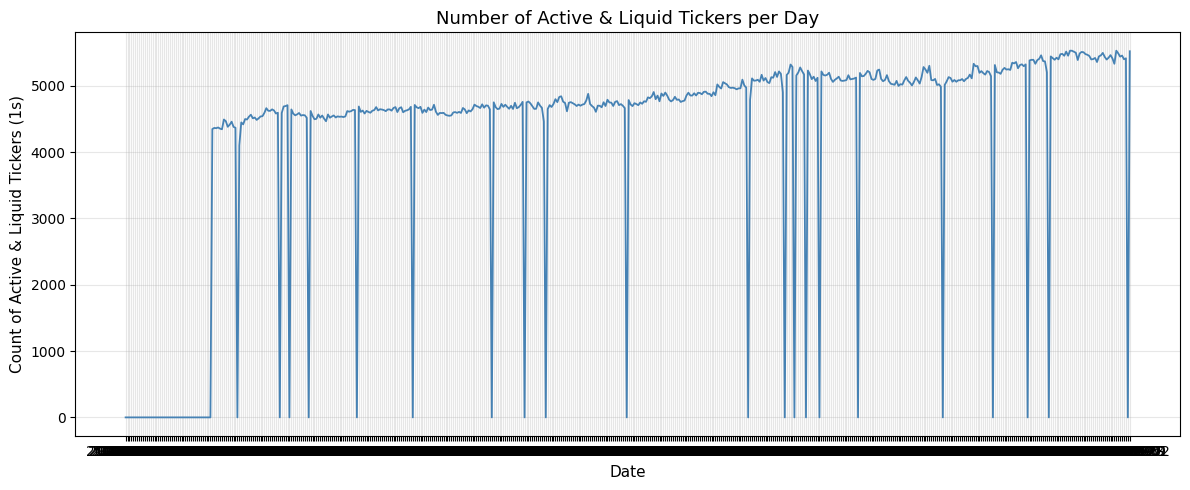

In [18]:
# count number of 1s per day
daily_active_counts = sample_space.sum(axis=1)

# plot
plt.figure(figsize=(12, 5))
plt.plot(daily_active_counts.index, daily_active_counts, lw=1.3, color='steelblue')
plt.title("Number of Active & Liquid Tickers per Day", fontsize=13)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Count of Active & Liquid Tickers (1s)", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
sample_space

ticker,A,AA,AACG,AADR,AAL,AALG,AAME,AAMI,AAOI,AAON,...,ZTWO,ZUMZ,ZURA,ZVIA,ZVRA,ZWS,ZYBT,ZYME,ZYXI,ZZZ
date,,,,,,,,,,,,,,,,,,,,,
2023-09-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2023-09-05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2023-09-06,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2023-09-07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2023-09-08,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-27,1,1,1,1,1,0,1,1,1,1,...,0,1,1,1,1,1,1,1,1,0
2025-08-28,1,1,1,1,1,0,0,1,1,1,...,0,1,1,1,1,1,1,1,1,0
2025-08-29,1,1,1,1,1,0,0,1,1,1,...,0,1,1,1,1,1,1,1,1,0


Supportive Functions: scale, delta, signedpower, Decay_Linear, indneutralize, ts_min, ts_max, ts_argmax:

In [20]:
 #Logreturn Matrix

def load_logret(close: pd.DataFrame,
                dividend: pd.DataFrame,
                split: pd.DataFrame) -> pd.DataFrame:
    simple_lr  = np.log(close / close.shift(1))
    adj_factor = 1 + split.fillna(0)
    adj_price  = close * adj_factor + dividend.fillna(0)
    ca_lr      = np.log(adj_price / close.shift(1))
    mask       = dividend.notna() | split.notna()
    simple_lr[mask]   = ca_lr[mask]
    return simple_lr

logret = load_logret(close, div, split)

In [21]:
logret

ticker,A,AA,AACG,AADR,AAL,AALG,AAME,AAMI,AAOI,AAON,...,ZTWO,ZUMZ,ZURA,ZVIA,ZVRA,ZWS,ZYBT,ZYME,ZYXI,ZZZ
date,,,,,,,,,,,,,,,,,,,,,
2023-09-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-06,-0.006676,-0.002976,-0.016394,-0.000678,0.002096,NaN,-0.034857,NaN,-0.039375,0.014198,...,NaN,0.025990,0.014451,0.003854,-0.009990,-0.001374,NaN,-0.017894,-0.019238,NaN
2023-09-07,-0.014347,-0.059694,-0.016667,-0.013960,-0.023298,NaN,-0.015088,NaN,-0.010497,0.007937,...,NaN,-0.002676,-0.054546,0.007663,0.056600,-0.004477,NaN,-0.033902,0.024166,NaN
2023-09-08,-0.019718,-0.012379,-0.008439,-0.009421,-0.001430,NaN,0.023969,NaN,-0.043124,-0.001981,...,NaN,-0.107685,-0.072245,-0.003824,-0.001899,-0.002765,NaN,0.022728,0.037220,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-27,0.003291,-0.004706,0.099298,-0.015467,-0.001522,-0.005817,-0.020203,-0.010607,-0.041537,0.000708,...,0.000393,0.076303,0.062072,-0.021979,-0.005328,0.010799,0.039586,0.006720,0.011976,0.004094
2025-08-28,0.051479,0.003766,0.103867,0.004751,0.009098,0.017202,-0.023600,0.012364,0.058151,0.004356,...,-0.000197,-0.037993,-0.018692,0.000000,-0.006431,-0.014280,0.012479,-0.006046,-0.024098,0.002740
2025-08-29,0.005586,0.008423,-0.027274,0.001427,0.009016,0.019587,0.005952,-0.005869,-0.051934,-0.025824,...,0.000295,-0.021296,-0.038466,0.036368,-0.025042,-0.011617,0.053770,-0.002024,0.000000,-0.013748


In [22]:
open_shifted        = open_m.shift(1)
high_shifted        = high.shift(1)
close_shifted       = close.shift(1)
low_shifted         = low.shift(1)
volume_shifted      = volume.shift(1)
amount_shifted      = amount.shift(1)

# Derived features (also shift once)
div_shifted      = div.shift(1)
split_shifted    = split.shift(1)
logret_shifted   = logret.shift(1)

sector_aligned_shifted      = sector_matrix.shift(1)
subindustry_aligned_shifted = subindustry.shift(1)
industry_aligned_shifted    = industry.shift(1)

adv5_shifted   = volume.rolling(window=5,   min_periods=5).mean().shift(1)
adv10_shifted  = volume.rolling(window=10,  min_periods=10).mean().shift(1)
adv15_shifted  = volume.rolling(window=15,  min_periods=15).mean().shift(1)
adv20_shifted  = volume.rolling(window=20,  min_periods=20).mean().shift(1)
adv30_shifted  = volume.rolling(window=30,  min_periods=30).mean().shift(1)
adv40_shifted  = volume.rolling(window=40,  min_periods=40).mean().shift(1)
adv50_shifted  = volume.rolling(window=50,  min_periods=50).mean().shift(1)
adv60_shifted  = volume.rolling(window=60,  min_periods=60).mean().shift(1)
adv81_shifted  = volume.rolling(window=81,  min_periods=81).mean().shift(1)
adv120_shifted = volume.rolling(window=120, min_periods=120).mean().shift(1)
adv150_shifted = volume.rolling(window=150, min_periods=150).mean().shift(1)
adv180_shifted = volume.rolling(window=180, min_periods=180).mean().shift(1)

vwap_shifted = amount.div(volume).replace([np.inf, -np.inf], np.nan).shift(1)


In [23]:

# ─── Alpha 1 ────────────────────────────────────────────────────────────────
def load_alpha1(close_shifted, logret_shifted, sample_space):
    r    = logret_shifted
    s20  = stddev(r, 20)
    base = s20.where(r < 0, close_shifted)
    p2   = signedpower(base, 2.0)
    k    = ts_argmax(p2, 5)
    alpha = rank(k) - 0.5
    return alpha.where(sample_space == 1)

# ─── Alpha 2 ────────────────────────────────────────────────────────────────
def load_alpha2(close_shifted, open_shifted, volume_shifted, sample_space):
    r1 = rank(delta(np.log(volume_shifted), 2))
    r2 = rank((close_shifted - open_shifted) / open_shifted)
    alpha = -correlation(r1, r2, 6)
    return alpha.where(sample_space == 1)

# ─── Alpha 3 ────────────────────────────────────────────────────────────────
def load_alpha3(open_shifted, volume_shifted, sample_space):
    alpha = -correlation(rank(open_shifted), rank(volume_shifted), 10)
    return alpha.where(sample_space == 1)

# ─── Alpha 4 ────────────────────────────────────────────────────────────────
def load_alpha4(low_shifted, sample_space):
    alpha = -ts_rank(rank(low_shifted), 9)
    return alpha.where(sample_space == 1)

# ─── Alpha 5 ────────────────────────────────────────────────────────────────
def load_alpha5(open_shifted, close_shifted, vwap_shifted, sample_space):
    part1 = rank(open_shifted - ts_sum(vwap_shifted, 10) / 10)
    part2 = -abs(rank(close_shifted - vwap_shifted))
    alpha = part1 * part2
    return alpha.where(sample_space == 1)

# ─── Alpha 6 ────────────────────────────────────────────────────────────────
def load_alpha6(open_shifted, volume_shifted, sample_space):
    alpha = -correlation(open_shifted, volume_shifted, 10)
    return alpha.where(sample_space == 1)

# ─── Alpha 7 ────────────────────────────────────────────────────────────────
def load_alpha7(close_shifted, adv20_shifted, volume_shifted, sample_space):
    d7   = delta(close_shifted, 7)
    core = -ts_rank(abs(d7), 60) * sign(d7)
    alpha = core.where(adv20_shifted < volume_shifted, -1.0)
    return alpha.where(sample_space == 1)

# ─── Alpha 8 ────────────────────────────────────────────────────────────────
def load_alpha8(open_shifted, logret_shifted, sample_space):
    term  = ts_sum(open_shifted, 5) * ts_sum(logret_shifted, 5)
    alpha = -rank(term - delay(term, 10))
    return alpha.where(sample_space == 1)

# ─── Alpha 9 ────────────────────────────────────────────────────────────────
def load_alpha9(close_shifted, sample_space):
    d1    = delta(close_shifted, 1)
    cond1 = ts_min(d1, 5) > 0
    cond2 = ts_max(d1, 5) < 0
    alpha = d1.where(cond1 | cond2, -d1)
    return alpha.where(sample_space == 1)

# ─── Alpha 10 ───────────────────────────────────────────────────────────────
def load_alpha10(close_shifted, sample_space):
    d1    = delta(close_shifted, 1)
    cond1 = ts_min(d1, 4) > 0
    cond2 = ts_max(d1, 4) < 0
    tmp   = d1.where(cond1 | cond2, -d1)
    alpha = rank(tmp)
    return alpha.where(sample_space == 1)

# ─── Alpha 11 ───────────────────────────────────────────────────────────────
def load_alpha11(close_shifted, vwap_shifted, volume_shifted, sample_space):
    diff  = vwap_shifted - close_shifted
    part  = rank(ts_max(diff, 3)) + rank(ts_min(diff, 3))
    alpha = part * rank(delta(volume_shifted, 3))
    return alpha.where(sample_space == 1)

# ─── Alpha 12 ───────────────────────────────────────────────────────────────
def load_alpha12(close_shifted, volume_shifted, sample_space):
    alpha = sign(delta(volume_shifted, 1)) * (-delta(close_shifted, 1))
    return alpha.where(sample_space == 1)

# ─── Alpha 13 ───────────────────────────────────────────────────────────────
def load_alpha13(close_shifted, volume_shifted, sample_space):
    alpha = -rank(covariance(rank(close_shifted), rank(volume_shifted), 5))
    return alpha.where(sample_space == 1)

# ─── Alpha 14 ───────────────────────────────────────────────────────────────
def load_alpha14(open_shifted, volume_shifted, logret_shifted, sample_space):
    part1 = -rank(delta(logret_shifted, 3))
    alpha = part1 * correlation(open_shifted, volume_shifted, 10)
    return alpha.where(sample_space == 1)

# ─── Alpha 15 ───────────────────────────────────────────────────────────────
def load_alpha15(high_shifted, volume_shifted, sample_space):
    corr  = correlation(rank(high_shifted), rank(volume_shifted), 3)
    alpha = -ts_sum(rank(corr), 3)
    return alpha.where(sample_space == 1)

# ─── Alpha 16 ───────────────────────────────────────────────────────────────
def load_alpha16(high_shifted, volume_shifted, sample_space):
    alpha = -rank(covariance(rank(high_shifted), rank(volume_shifted), 5))
    return alpha.where(sample_space == 1)

# ─── Alpha 17 ───────────────────────────────────────────────────────────────
def load_alpha17(close_shifted, volume_shifted, adv20_shifted, sample_space):
    part1 = -rank(ts_rank(close_shifted, 10))
    part2 = rank(delta(delta(close_shifted, 1), 1))
    part3 = rank(ts_rank(volume_shifted / adv20_shifted, 5))
    alpha = part1 * part2 * part3
    return alpha.where(sample_space == 1)

# ─── Alpha 18 ───────────────────────────────────────────────────────────────
def load_alpha18(close_shifted, open_shifted, sample_space):
    term  = stddev(abs(close_shifted - open_shifted), 5) + (close_shifted - open_shifted)
    corr  = correlation(close_shifted, open_shifted, 10)
    alpha = -rank(term + corr)
    return alpha.where(sample_space == 1)

# ─── Alpha 19 ───────────────────────────────────────────────────────────────
def load_alpha19(close_shifted, logret_shifted, sample_space):
    expr  = (close_shifted - delay(close_shifted, 7)) + delta(close_shifted, 7)
    part1 = -sign(expr)
    part2 = 1 + rank(1 + ts_sum(logret_shifted, 250))
    alpha = part1 * part2
    return alpha.where(sample_space == 1)

# ─── Alpha 20 ───────────────────────────────────────────────────────────────
def load_alpha20(open_shifted, high_shifted, close_shifted, low_shifted, sample_space):
    r1 = rank(open_shifted - delay(high_shifted, 1))
    r2 = rank(open_shifted - delay(close_shifted, 1))
    r3 = rank(open_shifted - delay(low_shifted, 1))
    alpha = -r1 * r2 * r3
    return alpha.where(sample_space == 1)

# ─── Alpha 21 ───────────────────────────────────────────────────────────────
def load_alpha21(close_shifted, volume_shifted, adv20_shifted, sample_space):
    m8   = ts_sum(close_shifted, 8) / 8
    s8   = stddev(close_shifted, 8)
    m2   = ts_sum(close_shifted, 2) / 2
    vr   = volume_shifted / adv20_shifted

    condA = (m8 + s8) < m2
    condB = m2 < (m8 - s8)
    condC = vr >= 1

    val = pd.DataFrame(-1.0, index=close_shifted.index, columns=close_shifted.columns)
    val = val.where(~condB,  1.0)
    val = val.where(~condA, -1.0)
    maskC = (~condA) & (~condB) & condC
    val = val.where(~maskC, 1.0)

    return val.where(sample_space == 1)

# ─── Alpha 22 ───────────────────────────────────────────────────────────────
def load_alpha22(high_shifted, volume_shifted, close_shifted, sample_space):
    corr5       = correlation(high_shifted, volume_shifted, 5)
    delta_corr5 = delta(corr5, 5)

    std20   = stddev(close_shifted, 20)
    r_std20 = rank(std20)

    val = -delta_corr5 * r_std20
    return val.where(sample_space == 1)

# ─── Alpha 23 ───────────────────────────────────────────────────────────────
def load_alpha23(high_shifted, sample_space):
    m20  = ts_sum(high_shifted, 20) / 20
    cond = m20 < high_shifted

    d2  = delta(high_shifted, 2)
    val = pd.DataFrame(0.0, index=high_shifted.index, columns=high_shifted.columns)
    val = val.where(~cond, -d2)

    return val.where(sample_space == 1)

# ─── Alpha 24 ───────────────────────────────────────────────────────────────
def load_alpha24(close_shifted, sample_space):
    m100   = ts_sum(close_shifted, 100) / 100
    d_m100 = delta(m100, 100)
    clk100 = delay(close_shifted, 100)
    ratio  = d_m100.div(clk100)

    tsmin100 = ts_min(close_shifted, 100)
    cond     = ratio <= 0.05

    partA = - (close_shifted - tsmin100)
    partB = - delta(close_shifted, 3)

    val = pd.DataFrame(index=close_shifted.index, columns=close_shifted.columns, dtype=float)
    val = val.where(~cond, partA)
    val = val.fillna(partB)

    return val.where(sample_space == 1)

# ─── Alpha 25 ───────────────────────────────────────────────────────────────
def load_alpha25(logret_shifted, adv20_shifted, vwap_shifted,
                 high_shifted, close_shifted, sample_space):
    expr   = ((-1 * logret_shifted) * adv20_shifted) * vwap_shifted * (high_shifted - close_shifted)
    ranked = rank(expr)
    return ranked.where(sample_space == 1)

# ─── Alpha 26 ───────────────────────────────────────────────────────────────
def load_alpha26(volume_shifted, high_shifted, sample_space):
    tr_v5  = ts_rank(volume_shifted, 5)
    tr_h5  = ts_rank(high_shifted, 5)

    corr5 = correlation(tr_v5, tr_h5, 5)
    tmax3 = ts_max(corr5, 3)

    val = -tmax3
    return val.where(sample_space == 1)

# ─── Alpha 27 ───────────────────────────────────────────────────────────────
def load_alpha27(volume_shifted, amount_shifted, sample_space):
    v1       = volume_shifted
    vw1      = amount_shifted / volume_shifted
    rv       = rank(v1)
    rvw      = rank(vw1)

    corr6   = correlation(rv, rvw, 6)
    m2_corr = ts_sum(corr6, 2) / 2
    r_m2    = rank(m2_corr)

    val = pd.DataFrame(1.0, index=volume_shifted.index, columns=volume_shifted.columns)
    val = val.where(~(r_m2 > 0.5), -1.0)
    return val.where(sample_space == 1)

# ─── Alpha 28 ───────────────────────────────────────────────────────────────
def load_alpha28(adv20_shifted, low_shifted, high_shifted, close_shifted, sample_space):
    corr5 = correlation(adv20_shifted, low_shifted, 5)

    mid  = (high_shifted + low_shifted) * 0.5
    expr = corr5 + mid - close_shifted

    scaled = scale(expr)
    return scaled.where(sample_space == 1)

# ─── Alpha 29 ───────────────────────────────────────────────────────────────
def load_alpha29(close_shifted, logret_shifted, sample_space):
    neg_delta = -delta(close_shifted, 1)
    r1        = rank(neg_delta)
    r2        = rank(r1)

    tr2   = ts_rank(r2, 2)
    tmin5 = ts_min(tr2, 5)

    sum2     = ts_sum(tmin5, 2)
    log_sum2 = np.log(sum2)
    scaled   = scale(log_sum2)
    ranked   = rank(scaled)

    part1 = ts_min(ranked, 5)
    part2 = ts_rank(-logret_shifted.shift(6), 5)

    val = part1 + part2
    return val.where(sample_space == 1)

# ─── Alpha 30 ───────────────────────────────────────────────────────────────
def load_alpha30(close_shifted, volume_shifted, sample_space):
    d1   = close_shifted - delay(close_shifted, 1)
    d2   = delay(close_shifted, 1) - delay(close_shifted, 2)
    d3   = delay(close_shifted, 2) - delay(close_shifted, 3)

    expr   = sign(d1) + sign(d2) + sign(d3)
    r_expr = rank(expr)

    vol5  = ts_sum(volume_shifted, 5)
    vol20 = ts_sum(volume_shifted, 20)

    val = (1.0 - r_expr) * (vol5 / vol20)
    return val.where(sample_space == 1)

# ─── Alpha 31 ───────────────────────────────────────────────────────────────
def load_alpha31(close_shifted, adv20_shifted, low_shifted, sample_space):
    d10   = delta(close_shifted, 10)
    r_d10 = rank(d10)
    r_r_d10 = rank(r_d10)
    neg_r_r_d10 = -r_r_d10

    dl = decay_linear(neg_r_r_d10, 10)
    r1 = rank(dl)
    r2 = rank(r1)
    r3 = rank(r2)

    d3      = delta(close_shifted, 3)
    r_neg_d3= rank(-d3)

    corr12       = correlation(adv20_shifted, low_shifted, 12)
    scaled_corr12 = scale(corr12)
    s_corr       = sign(scaled_corr12)

    val = r3 + r_neg_d3 + s_corr
    return val.where(sample_space == 1)

# ─── Alpha 32 ───────────────────────────────────────────────────────────────
def load_alpha32(close_shifted, vwap_shifted, sample_space):
    mean7  = ts_sum(close_shifted, 7) / 7
    expr1  = mean7 - close_shifted
    s1     = scale(expr1)

    corr230 = correlation(vwap_shifted, delay(close_shifted, 5), 230)
    s2      = scale(corr230)

    val = s1 + 20.0 * s2
    return val.where(sample_space == 1)

# ─── Alpha 33 ───────────────────────────────────────────────────────────────
def load_alpha33(open_shifted, close_shifted, sample_space):
    expr   = (open_shifted / close_shifted) - 1.0
    r_expr = rank(expr)
    return r_expr.where(sample_space == 1)

# ─── Alpha 34 ───────────────────────────────────────────────────────────────
def load_alpha34(close_shifted, logret_shifted, sample_space):
    sd2     = stddev(logret_shifted, 2)
    sd5     = stddev(logret_shifted, 5)
    ratio   = sd2.div(sd5)
    r_ratio = rank(ratio)
    part1   = 1.0 - r_ratio

    d1      = delta(close_shifted, 1)
    r_d1    = rank(d1)
    part2   = 1.0 - r_d1

    expr    = part1 + part2
    r_expr  = rank(expr)
    return r_expr.where(sample_space == 1)

# ─── Alpha 35 ───────────────────────────────────────────────────────────────
def load_alpha35(close_shifted, high_shifted, low_shifted, volume_shifted,
                 logret_shifted, sample_space):
    tr_vol32   = ts_rank(volume_shifted, 32)

    expr2      = (close_shifted + high_shifted) - low_shifted
    tr_expr2_16= ts_rank(expr2, 16)
    part2      = 1.0 - tr_expr2_16

    tr_ret32 = ts_rank(logret_shifted, 32)
    part3    = 1.0 - tr_ret32

    val = tr_vol32 * part2 * part3
    return val.where(sample_space == 1)

# ─── Alpha 36 ───────────────────────────────────────────────────────────────
def load_alpha36(close_shifted, open_shifted, volume_shifted, vwap_shifted,
                 adv20_shifted, logret_shifted, sample_space):
    A         = close_shifted - open_shifted
    B         = delay(volume_shifted, 1)
    corr15    = correlation(A, B, 15)
    r_corr15  = rank(corr15)
    partA     = 2.21 * r_corr15

    r_open_minus_close = rank(open_shifted - close_shifted)
    partB    = 0.7 * r_open_minus_close

    delayed_neg_ret = delay(-logret_shifted, 6)
    tr_delayed_neg_ret_5 = ts_rank(delayed_neg_ret, 5)
    r_tr     = rank(tr_delayed_neg_ret_5)
    partC    = 0.73 * r_tr

    corr_vwap_adv20_6 = correlation(vwap_shifted, adv20_shifted, 6).abs()
    partD   = rank(corr_vwap_adv20_6)

    mean200 = ts_sum(close_shifted, 200) / 200
    exprE   = (mean200 - open_shifted) * (close_shifted - open_shifted)
    partE   = 0.6 * rank(exprE)

    val = partA + partB + partC + partD + partE
    return val.where(sample_space == 1)

# ─── Alpha 37 ───────────────────────────────────────────────────────────────
def load_alpha37(open_shifted, close_shifted, sample_space):
    A        = (open_shifted - close_shifted)
    corr200  = correlation(delay(A, 1), close_shifted, 200)
    r_corr200 = rank(corr200)

    r_open_minus_close = rank(open_shifted - close_shifted)

    val = r_corr200 + r_open_minus_close
    return val.where(sample_space == 1)

# ─── Alpha 38 ───────────────────────────────────────────────────────────────
def load_alpha38(close_shifted, open_shifted, sample_space):
    tr_close10       = ts_rank(close_shifted, 10)
    r_tr_close10     = rank(tr_close10)
    part1            = -r_tr_close10

    r_close_over_open= rank(close_shifted / open_shifted)

    val = part1 * r_close_over_open
    return val.where(sample_space == 1)

# ─── Alpha 39 ───────────────────────────────────────────────────────────────
def load_alpha39(close_shifted, volume_shifted, adv20_shifted,
                 logret_shifted, sample_space):
    ratio_vol_adv20 = volume_shifted.div(adv20_shifted)
    dl_ratio        = decay_linear(ratio_vol_adv20, 9)
    r_dl            = rank(dl_ratio)
    part_inner      = 1.0 - r_dl

    delta7    = delta(close_shifted, 7)
    exprA     = delta7 * part_inner
    r_exprA   = rank(exprA)
    partA     = -r_exprA

    sum_ret250 = ts_sum(logret_shifted, 250)
    r_sum_ret250 = rank(sum_ret250)
    partB     = 1.0 + r_sum_ret250

    val = partA * partB
    return val.where(sample_space == 1)

# ─── Alpha 40 ───────────────────────────────────────────────────────────────
def load_alpha40(high_shifted, volume_shifted, sample_space):
    s10    = stddev(high_shifted, 10)
    r_s10  = rank(s10)
    corr10 = correlation(high_shifted, volume_shifted, 10)
    val    = -r_s10 * corr10
    return val.where(sample_space == 1)

# ─── Alpha 41 ───────────────────────────────────────────────────────────────
def load_alpha41(high_shifted, low_shifted, vwap_shifted, sample_space):
    geom_hl = (high_shifted * low_shifted).pow(0.5)
    val     = geom_hl - vwap_shifted
    return val.where(sample_space == 1)

# ─── Alpha 43 ───────────────────────────────────────────────────────────────
def load_alpha43(close_shifted, volume_shifted, adv20_shifted, sample_space):
    ratio_v = volume_shifted.div(adv20_shifted).replace([np.inf, -np.inf], np.nan)
    tr1     = ts_rank(ratio_v, 20)
    d7      = delta(close_shifted, 7)
    tr2     = ts_rank(-d7, 8)
    val     = tr1 * tr2
    return val.where(sample_space == 1)

# ─── Alpha 44 ───────────────────────────────────────────────────────────────
def load_alpha44(high_shifted, volume_shifted, sample_space):
    r_vol     = rank(volume_shifted)
    corr5     = correlation(high_shifted, r_vol, 5)
    val       = -corr5
    return val.where(sample_space == 1)

# ─── Alpha 45 ───────────────────────────────────────────────────────────────
def load_alpha45(close_shifted, volume_shifted, sample_space):
    d5        = delay(close_shifted, 5)
    sma20     = ts_sum(d5, 20) / 20
    r_sma20   = rank(sma20)
    corr_c_v2 = correlation(close_shifted, volume_shifted, 2)
    sum5      = ts_sum(close_shifted, 5)
    sum20     = ts_sum(close_shifted, 20)
    corr_sum2 = correlation(sum5, sum20, 2)
    r_corrsum = rank(corr_sum2)
    val       = - (r_sma20 * corr_c_v2 * r_corrsum)
    return val.where(sample_space == 1)

# ─── Alpha 46 ───────────────────────────────────────────────────────────────
def load_alpha46(close_shifted, sample_space):
    c    = close_shifted
    c10  = delay(c, 10)
    c20  = delay(c, 20)
    c1   = delay(c, 1)
    term = ((c20 - c10) / 10.0) - ((c10 - c) / 10.0)

    val   = pd.DataFrame(index=c.index, columns=c.columns, dtype=float)
    mask1 = term > 0.25
    val   = val.where(~mask1, -1.0)
    mask2 = (~mask1) & (term < 0.0)
    val   = val.where(~mask2, 1.0)
    mask3 = (~mask1) & (~mask2)
    val   = val.where(~mask3, -1.0 * (c - c1))
    return val.where(sample_space == 1)

# ─── Alpha 47 ───────────────────────────────────────────────────────────────
def load_alpha47(close_shifted, high_shifted, volume_shifted,
                 adv20_shifted, vwap_shifted, sample_space):
    inv_c     = close_shifted.rpow(-1)
    r_invc    = rank(inv_c)
    partA1    = r_invc * volume_shifted.div(adv20_shifted)

    diff_hc   = high_shifted - close_shifted
    r_diff_hc = rank(diff_hc)
    sma_h5    = ts_sum(high_shifted, 5) / 5
    partA2    = high_shifted * r_diff_hc.div(sma_h5)

    A         = partA1 * partA2
    r_vwd     = rank(vwap_shifted - delay(vwap_shifted, 5))

    val = A - r_vwd
    return val.where(sample_space == 1)

# ─── Alpha 49 ───────────────────────────────────────────────────────────────
def load_alpha49(close_shifted, sample_space):
    c    = close_shifted
    c10  = delay(c, 10)
    c20  = delay(c, 20)
    c1   = delay(c, 1)
    term = ((c20 - c10) / 10.0) - ((c10 - c) / 10.0)

    val   = pd.DataFrame(index=c.index, columns=c.columns, dtype=float)
    mask1 = term < -0.1
    val   = val.where(~mask1, 1.0)
    val   = val.where(mask1, -1.0 * (c - c1))
    return val.where(sample_space == 1)

# ─── Alpha 50 ───────────────────────────────────────────────────────────────
def load_alpha50(volume_shifted, vwap_shifted, sample_space):
    r_vol  = rank(volume_shifted)
    r_vwap = rank(vwap_shifted)
    corr5  = correlation(r_vol, r_vwap, 5)
    r_corr = rank(corr5)
    tmax5  = ts_max(r_corr, 5)
    val    = -tmax5
    return val.where(sample_space == 1)

# ─── Alpha 51 ───────────────────────────────────────────────────────────────
def load_alpha51(close_shifted, sample_space):
    c    = close_shifted
    c10  = delay(c, 10)
    c20  = delay(c, 20)
    c1   = delay(c, 1)
    term = ((c20 - c10) / 10.0) - ((c10 - c) / 10.0)

    val  = pd.DataFrame(index=c.index, columns=c.columns, dtype=float)
    mask = term < -0.05
    val  = val.where(~mask, 1.0)
    val  = val.where(mask, -1.0 * (c - c1))
    return val.where(sample_space == 1)

# ─── Alpha 52 ───────────────────────────────────────────────────────────────
def load_alpha52(low_shifted, logret_shifted, volume_shifted, sample_space):
    tmin5      = ts_min(low_shifted, 5)
    tmin5_d5   = delay(tmin5, 5)
    partA      = -tmin5 + tmin5_d5

    sum240     = ts_sum(logret_shifted, 240)
    sum20      = ts_sum(logret_shifted, 20)
    ratio      = (sum240 - sum20).div(220.0)
    r_ratio    = rank(ratio)

    tr_vol5    = ts_rank(volume_shifted, 5)

    val        = partA * r_ratio * tr_vol5
    return val.where(sample_space == 1)

# ─── Alpha 55 ───────────────────────────────────────────────────────────────
def load_alpha55(close_shifted, high_shifted, low_shifted,
                 volume_shifted, sample_space):
    tmin12     = ts_min(low_shifted, 12)
    tmax12     = ts_max(high_shifted, 12)
    denom      = (tmax12 - tmin12).replace(0, np.nan)
    ratio      = (close_shifted - tmin12).div(denom)
    r_ratio    = rank(ratio)
    r_vol      = rank(volume_shifted)
    corr6      = correlation(r_ratio, r_vol, 6)
    val        = -corr6
    return val.where(sample_space == 1)

# ─── Alpha 57 ───────────────────────────────────────────────────────────────
def load_alpha57(close_shifted, vwap_shifted, sample_space):
    def _argmax(arr: np.ndarray) -> float:
        return float(np.argmax(arr))
    argmax30   = close_shifted.rolling(window=30, min_periods=30).apply(_argmax, raw=True)
    r_argmax30 = rank(argmax30)
    dl2        = decay_linear(r_argmax30, 2)
    expr       = (close_shifted - vwap_shifted).div(dl2.replace(0, np.nan))
    val        = -expr
    return val.where(sample_space == 1)

# ─── Alpha 58 ───────────────────────────────────────────────────────────────
def load_alpha58(vwap_shifted, volume_shifted,
                 sector_aligned_shifted, sample_space):
    w_corr  = int(np.floor(3.92795))   # =3
    w_decay = int(np.floor(7.89291))   # =7
    w_rank  = int(np.floor(5.50322))   # =5

    vwap_ind = indneutralize(vwap_shifted, sector_aligned_shifted)
    corr3    = correlation(vwap_ind, volume_shifted, w_corr)
    decay7   = decay_linear(corr3, w_decay)
    rank5    = ts_rank(decay7, w_rank)
    val      = -rank5
    return val.where(sample_space == 1)

# ─── Alpha 59 ───────────────────────────────────────────────────────────────
def load_alpha59(vwap_shifted, volume_shifted,
                 industry_aligned_shifted, sample_space):
    w_corr  = int(np.floor(4.25197))    # =4
    w_decay = int(np.floor(16.2289))    # =16
    w_rank  = int(np.floor(8.19648))    # =8

    vwap_mix = vwap_shifted  # since 0.728317 + (1 - 0.728317) = 1
    vwap_ind = indneutralize(vwap_mix, industry_aligned_shifted)
    corr4    = correlation(vwap_ind, volume_shifted, w_corr)
    decay16  = decay_linear(corr4, w_decay)
    rank8    = ts_rank(decay16, w_rank)
    val      = -rank8
    return val.where(sample_space == 1)

# ─── Alpha 60 ───────────────────────────────────────────────────────────────
def load_alpha60(close_shifted, high_shifted, low_shifted,
                 volume_shifted, sample_space):
    num = (close_shifted - low_shifted) - (high_shifted - close_shifted)
    den = (high_shifted - low_shifted).replace(0, np.nan)
    X   = num.div(den)

    A_r = rank(X * volume_shifted)
    A_s = scale(A_r)

    B_r = rank(ts_argmax(close_shifted, 10))
    B_s = scale(B_r)

    alpha = - (2 * A_s - B_s)
    return alpha.where(sample_space == 1)

# ─── Alpha 61 ───────────────────────────────────────────────────────────────
def load_alpha61(vwap_shifted, adv180_shifted, sample_space):
    left   = rank(vwap_shifted - ts_min(vwap_shifted, 16.1219))
    right  = rank(correlation(vwap_shifted, adv180_shifted, 17.9282))
    alpha  = left.lt(right).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 62 ───────────────────────────────────────────────────────────────
def load_alpha62(vwap_shifted, adv20_shifted, open_shifted,
                 high_shifted, low_shifted, sample_space):
    sum_adv  = ts_sum(adv20_shifted, 22.4101)
    left     = rank(correlation(vwap_shifted, sum_adv, 9.91009))

    r_open   = rank(open_shifted)
    r_mid    = rank((high_shifted + low_shifted) * 0.5)
    r_high   = rank(high_shifted)
    cond     = (r_open + r_open).lt(r_mid + r_high)
    right    = rank(cond.astype(float))

    alpha    = - left.lt(right).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 63 ───────────────────────────────────────────────────────────────
def load_alpha63(vwap_shifted, adv180_shifted, close_shifted,
                 open_shifted, high_shifted, low_shifted,
                 industry_aligned_shifted, sample_space):
    ind_cl   = indneutralize(close_shifted, industry_aligned_shifted)
    d1       = delta(ind_cl, 2.25164)
    d1_dec   = decay_linear(d1, 8.22237)
    p1       = rank(d1_dec)

    mix      = vwap_shifted * 0.318108 + open_shifted * (1 - 0.318108)
    sum2     = ts_sum(adv180_shifted, 37.2467)
    c2       = correlation(mix, sum2, 13.557)
    d2_dec   = decay_linear(c2, 12.2883)
    p2       = rank(d2_dec)

    alpha    = - (p1 - p2)
    return alpha.where(sample_space == 1)

# ─── Alpha 64 ───────────────────────────────────────────────────────────────
def load_alpha64(vwap_shifted, adv120_shifted, close_shifted,
                 high_shifted, low_shifted, open_shifted, sample_space):
    mix1     = open_shifted * 0.178404 + low_shifted * (1 - 0.178404)
    sum1     = ts_sum(mix1, 12.7054)
    sum_adv  = ts_sum(adv120_shifted, 12.7054)
    left     = rank(correlation(sum1, sum_adv, 16.6208))

    mix2     = ((high_shifted + low_shifted) * 0.5) * 0.178404 + vwap_shifted * (1 - 0.178404)
    right    = rank(delta(mix2, 3.69741))

    alpha    = -left.lt(right).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 65 ───────────────────────────────────────────────────────────────
def load_alpha65(vwap_shifted, adv60_shifted, open_shifted, sample_space):
    sum_adv  = ts_sum(adv60_shifted, 8.6911)
    mix      = open_shifted * 0.00817205 + vwap_shifted * (1 - 0.00817205)
    left     = rank(correlation(mix, sum_adv, 6.40374))
    right    = rank(open_shifted - ts_min(open_shifted, 13.635))
    alpha    = -left.lt(right).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 66 ───────────────────────────────────────────────────────────────
def load_alpha66(vwap_shifted, high_shifted, low_shifted,
                 open_shifted, sample_space):
    d1       = delta(vwap_shifted, 3.51013)
    d1_dec   = decay_linear(d1, 7.23052)
    p1       = rank(d1_dec)

    mix2_num = low_shifted - vwap_shifted
    mix2_den = (open_shifted - (high_shifted + low_shifted) * 0.5).replace(0, np.nan)
    mix2     = mix2_num.div(mix2_den)
    d2_dec   = decay_linear(mix2, 11.4157)
    p2       = ts_rank(d2_dec, 6.72611)

    alpha    = - (p1 + p2)
    return alpha.where(sample_space == 1)

# ─── Alpha 67 ───────────────────────────────────────────────────────────────
def load_alpha67(vwap_shifted, adv20_shifted,
                 sector_aligned_shifted, subindustry_aligned_shifted,
                 high_shifted, sample_space):
    w_min    = 2.14593
    left     = rank(high_shifted - ts_min(high_shifted, w_min))

    vwap_n   = indneutralize(vwap_shifted, sector_aligned_shifted)
    adv_n    = indneutralize(adv20_shifted, subindustry_aligned_shifted)
    w_c      = 6.02936
    right    = rank(correlation(vwap_n, adv_n, w_c))

    alpha    = - (left ** right)
    return alpha.where(sample_space == 1)

# ─── Alpha 68 ───────────────────────────────────────────────────────────────
def load_alpha68(high_shifted, adv15_shifted, close_shifted,
                 low_shifted, sample_space):
    r_high   = rank(high_shifted)
    r_adv15  = rank(adv15_shifted)
    corr1    = correlation(r_high, r_adv15, 8.91644)
    left     = ts_rank(corr1, 13.9333)

    mix2     = close_shifted * 0.518371 + low_shifted * (1 - 0.518371)
    right    = rank(delta(mix2, 1.06157))

    alpha    = - left.lt(right).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 69 ───────────────────────────────────────────────────────────────
def load_alpha69(vwap_shifted, close_shifted, adv20_shifted,
                 industry_aligned_shifted, sample_space):
    indn     = indneutralize(vwap_shifted, industry_aligned_shifted)
    d1       = delta(indn, 2.72412)
    m1       = ts_max(d1, 4.79344)
    left     = rank(m1)

    mix2     = close_shifted * 0.490655 + vwap_shifted * (1 - 0.490655)
    corr2    = correlation(mix2, adv20_shifted, 4.92416)
    right    = ts_rank(corr2, 9.0615)

    alpha    = - (left ** right)
    return alpha.where(sample_space == 1)

# ─── Alpha 70 ───────────────────────────────────────────────────────────────
def load_alpha70(vwap_shifted, close_shifted, adv50_shifted,
                 industry_aligned_shifted, sample_space):
    r1 = rank(delta(vwap_shifted, 1.29456))

    indc = indneutralize(close_shifted, industry_aligned_shifted)
    c2   = correlation(indc, adv50_shifted, 17.8256)
    t2   = ts_rank(c2, 17.9171)

    alpha = -(r1 ** t2)
    return alpha.where(sample_space == 1)

# ─── Alpha 71 ───────────────────────────────────────────────────────────────
def load_alpha71(close_shifted, adv180_shifted, low_shifted,
                 open_shifted, vwap_shifted, sample_space):
    t_close  = ts_rank(close_shifted, 3.43976)
    t_adv180 = ts_rank(adv180_shifted, 12.0647)
    c1       = correlation(t_close, t_adv180, 18.0175)
    d1       = decay_linear(c1, 4.20501)
    term1    = ts_rank(d1, 15.6948)

    expr     = (low_shifted + open_shifted) - 2 * vwap_shifted
    r_expr   = rank(expr)
    sqr_expr = r_expr * r_expr
    d2       = decay_linear(sqr_expr, 16.4662)
    term2    = ts_rank(d2, 4.4388)

    alpha    = term1.combine(term2, np.maximum)
    return alpha.where(sample_space == 1)

# ─── Alpha 72 ───────────────────────────────────────────────────────────────
def load_alpha72(high_shifted, low_shifted, adv40_shifted,
                 vwap_shifted, volume_shifted, sample_space):
    mid      = (high_shifted + low_shifted) * 0.5
    c1       = correlation(mid, adv40_shifted, 8.93345)
    d1       = decay_linear(c1, 10.1519)
    num_rank = rank(d1)

    r_vwap   = ts_rank(vwap_shifted, 3.72469)
    r_vol    = ts_rank(volume_shifted, 18.5188)
    c2       = correlation(r_vwap, r_vol, 6.86671)
    d2       = decay_linear(c2, 2.95011)
    den_rank = rank(d2)

    alpha    = num_rank.div(den_rank.replace(0, np.nan))
    return alpha.where(sample_space == 1)

# ─── Alpha 73 ───────────────────────────────────────────────────────────────
def load_alpha73(vwap_shifted, high_shifted, low_shifted,
                 open_shifted, sample_space):
    d1      = delta(vwap_shifted, 4.72775)
    d1_dec  = decay_linear(d1, 2.91864)
    r1      = rank(d1_dec)

    mix     = open_shifted * 0.147155 + low_shifted * (1 - 0.147155)
    d_mix   = delta(mix, 2.03608)
    expr2   = d_mix.div(mix.replace(0, np.nan)) * -1.0
    d2_dec  = decay_linear(expr2, 3.33829)
    r2      = ts_rank(d2_dec, 16.7411)

    alpha   = - r1.combine(r2, np.maximum)
    return alpha.where(sample_space == 1)

# ─── Alpha 74 ───────────────────────────────────────────────────────────────
def load_alpha74(close_shifted, high_shifted, vwap_shifted,
                 volume_shifted, adv30_shifted, sample_space):
    sum_adv = ts_sum(adv30_shifted, 37.4843)
    left    = rank(correlation(close_shifted, sum_adv, 15.1365))

    mix2    = high_shifted * 0.0261661 + vwap_shifted * (1 - 0.0261661)
    right   = rank(correlation(rank(mix2), rank(volume_shifted), 11.4791))

    alpha   = - left.lt(right).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 75 ───────────────────────────────────────────────────────────────
def load_alpha75(vwap_shifted, volume_shifted, low_shifted,
                 adv50_shifted, sample_space):
    left  = rank(correlation(vwap_shifted, volume_shifted, 4.24304))
    right = rank(correlation(rank(low_shifted), rank(adv50_shifted), 12.4413))
    alpha = left.lt(right).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 76 ───────────────────────────────────────────────────────────────
def load_alpha76(vwap_shifted, volume_shifted, low_shifted,
                 adv50_shifted, adv81_shifted,
                 sector_aligned_shifted, sample_space):
    d1      = delta(vwap_shifted, 1.24383)
    d1_dec  = decay_linear(d1, 11.8259)
    left    = rank(d1_dec)

    ind_l   = indneutralize(low_shifted, sector_aligned_shifted)
    c2      = correlation(ind_l, adv81_shifted, 8.14941)
    t1      = ts_rank(c2, 19.569)
    d2_dec  = decay_linear(t1, 17.1543)
    right   = ts_rank(d2_dec, 19.383)

    both    = pd.DataFrame(
                  np.maximum(left.values, right.values),
                  index=left.index,
                  columns=left.columns
              )
    alpha   = -both
    return alpha.where(sample_space == 1)

# ─── Alpha 77 ───────────────────────────────────────────────────────────────
def load_alpha77(high_shifted, low_shifted, vwap_shifted,
                 adv40_shifted, sample_space):
    expr1   = ((high_shifted + low_shifted) * 0.5) - vwap_shifted
    r1      = rank(decay_linear(expr1, 20.0451))

    mid     = (high_shifted + low_shifted) * 0.5
    c2      = correlation(mid, adv40_shifted, 3.1614)
    r2      = rank(decay_linear(c2, 5.64125))

    alpha   = r1.combine(r2, np.minimum)
    return alpha.where(sample_space == 1)

# ─── Alpha 78 ───────────────────────────────────────────────────────────────
def load_alpha78(low_shifted, vwap_shifted, volume_shifted,
                 adv40_shifted, sample_space):
    mix1    = low_shifted * 0.352233 + vwap_shifted * (1 - 0.352233)
    s1      = ts_sum(mix1, 19.7428)
    s2      = ts_sum(adv40_shifted, 19.7428)
    c1      = correlation(s1, s2, 6.83313)
    r1      = rank(c1)

    r_vwap  = rank(vwap_shifted)
    r_vol   = rank(volume_shifted)
    c2      = correlation(r_vwap, r_vol, 5.77492)
    r2      = rank(c2)

    alpha   = r1 ** r2
    return alpha.where(sample_space == 1)

# ─── Alpha 79 ───────────────────────────────────────────────────────────────
def load_alpha79(close_shifted, open_shifted,
                 sector_aligned_shifted, vwap_shifted,
                 adv150_shifted, sample_space):
    mix     = close_shifted * 0.60733 + open_shifted * (1 - 0.60733)
    ind_mix = indneutralize(mix, sector_aligned_shifted)
    r1      = rank(delta(ind_mix, 1.23438))

    t1      = ts_rank(vwap_shifted, 3.60973)
    t2      = ts_rank(adv150_shifted, 9.18637)
    c2      = correlation(t1, t2, 14.6644)
    r2      = rank(c2)

    alpha   = r1.lt(r2).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 80 ───────────────────────────────────────────────────────────────
def load_alpha80(open_shifted, high_shifted, volume_shifted,
                 adv10_shifted, industry_aligned_shifted, sample_space):
    mix     = open_shifted * 0.868128 + high_shifted * (1 - 0.868128)
    ind_mix = indneutralize(mix, industry_aligned_shifted)
    s1      = sign(delta(ind_mix, 4.04545))
    r1      = rank(s1)

    c2      = correlation(high_shifted, adv10_shifted, 5.11456)
    t2      = ts_rank(c2, 5.53756)

    alpha   = - (r1 ** t2)
    return alpha.where(sample_space == 1)

# ─── Alpha 81 ───────────────────────────────────────────────────────────────
def load_alpha81(vwap_shifted, volume_shifted, adv10_shifted, sample_space):
    s_adv10  = ts_sum(adv10_shifted, 49.6054)
    c1       = correlation(vwap_shifted, s_adv10, 8.47743)
    r_c1     = rank(c1)
    p4       = r_c1.pow(4)
    r4       = rank(p4)
    prod1    = product(r4, 14.9655)
    logp     = np.log(prod1)
    r_logp   = rank(logp)

    r_vwap   = rank(vwap_shifted)
    r_vol    = rank(volume_shifted)
    c2       = correlation(r_vwap, r_vol, 5.07914)
    r2       = rank(c2)

    alpha    = - r_logp.lt(r2).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 82 ───────────────────────────────────────────────────────────────
def load_alpha82(open_shifted, volume_shifted,
                 sector_aligned_shifted, sample_space):
    d1       = delta(open_shifted, 1.46063)
    d1_dec   = decay_linear(d1, 14.8717)
    r1       = rank(d1_dec)

    ind_v    = indneutralize(volume_shifted, sector_aligned_shifted)
    c2       = correlation(ind_v, open_shifted, 17.4842)
    d2_dec   = decay_linear(c2, 6.92131)
    t2       = ts_rank(d2_dec, 13.4283)

    alpha    = - r1.combine(t2, np.minimum)
    return alpha.where(sample_space == 1)

# ─── Alpha 83 ───────────────────────────────────────────────────────────────
def load_alpha83(high_shifted, low_shifted, close_shifted,
                 vwap_shifted, volume_shifted, sample_space):
    mid_range= (high_shifted - low_shifted).div(ts_sum(close_shifted, 5).div(5))
    d1       = delay(mid_range, 2)
    r1       = rank(d1)

    r_vol    = rank(volume_shifted)
    r2       = rank(r_vol)

    numerator= r1 * r2
    denom    = mid_range.div(vwap_shifted - close_shifted.replace(0, np.nan))
    alpha    = numerator.div(denom.replace(0, np.nan))
    return alpha.where(sample_space == 1)

# ─── Alpha 84 ───────────────────────────────────────────────────────────────
def load_alpha84(vwap_shifted, close_shifted, sample_space):
    d1       = vwap_shifted - ts_max(vwap_shifted, 15.3217)
    t1       = ts_rank(d1, 20.7127)
    pwr      = delta(close_shifted, 4.96796)
    alpha    = signedpower(t1, pwr)
    return alpha.where(sample_space == 1)

# ─── Alpha 85 ───────────────────────────────────────────────────────────────
def load_alpha85(high_shifted, low_shifted, close_shifted,
                 adv30_shifted, volume_shifted, sample_space):
    mix1 = high_shifted * 0.876703 + close_shifted * (1 - 0.876703)
    c1   = correlation(mix1, adv30_shifted, 9.61331)
    r1   = rank(c1)

    mid = (high_shifted + low_shifted) * 0.5
    t_mid = ts_rank(mid, 3.70596)
    t_vol = ts_rank(volume_shifted, 10.1595)
    c2    = correlation(t_mid, t_vol, 7.11408)
    r2    = rank(c2)

    alpha = r1 ** r2
    return alpha.where(sample_space == 1)

# ─── Alpha 86 ───────────────────────────────────────────────────────────────
def load_alpha86(open_shifted, close_shifted, vwap_shifted,
                 adv20_shifted, sample_space):
    s_adv    = ts_sum(adv20_shifted, 14.7444)
    c1       = correlation(close_shifted, s_adv, 6.00049)
    t1       = ts_rank(c1, 20.4195)

    expr     = (open_shifted + close_shifted) - (vwap_shifted + open_shifted)
    r2       = rank(expr)

    alpha    = - t1.lt(r2).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 87 ───────────────────────────────────────────────────────────────
def load_alpha87(close_shifted, vwap_shifted, adv81_shifted,
                 industry_aligned_shifted, sample_space):
    mix1     = close_shifted * 0.369701 + vwap_shifted * (1 - 0.369701)
    d1       = delta(mix1, 1.91233)
    d1_dec   = decay_linear(d1, 2.65461)
    r1       = rank(d1_dec)

    ind_a    = indneutralize(adv81_shifted, industry_aligned_shifted)
    c2       = correlation(ind_a, close_shifted, 13.4132).abs()
    d2_dec   = decay_linear(c2, 4.89768)
    t2       = ts_rank(d2_dec, 14.4535)

    alpha    = - r1.combine(t2, np.maximum)
    return alpha.where(sample_space == 1)

# ─── Alpha 88 ───────────────────────────────────────────────────────────────
def load_alpha88(open_shifted, high_shifted, low_shifted, close_shifted,
                 adv60_shifted, sample_space):
    expr1    = rank(open_shifted) + rank(low_shifted) - (rank(high_shifted) + rank(close_shifted))
    d1       = decay_linear(expr1, 8.06882)
    r1       = rank(d1)

    t1       = ts_rank(close_shifted, 8.44728)
    t2       = ts_rank(adv60_shifted, 20.6966)
    c2       = correlation(t1, t2, 8.01266)
    d2_dec   = decay_linear(c2, 6.65053)
    r2       = ts_rank(d2_dec, 2.61957)

    alpha    = r1.combine(r2, np.minimum)
    return alpha.where(sample_space == 1)

# ─── Alpha 89 ───────────────────────────────────────────────────────────────
def load_alpha89(vwap_shifted, close_shifted, low_shifted,
                 adv10_shifted, industry_aligned_shifted, sample_space):
    low_mix  = low_shifted
    c1       = correlation(low_mix, adv10_shifted, 6.94279)
    d1_dec   = decay_linear(c1, 5.51607)
    left     = ts_rank(d1_dec, 3.79744)

    ind_v    = indneutralize(vwap_shifted, industry_aligned_shifted)
    d2       = delta(ind_v, 3.48158)
    d2_dec   = decay_linear(d2, 10.1466)
    right    = ts_rank(d2_dec, 15.3012)

    alpha    = left - right
    return alpha.where(sample_space == 1)

# ─── Alpha 90 ───────────────────────────────────────────────────────────────
def load_alpha90(close_shifted, low_shifted, adv40_shifted,
                 subindustry_aligned_shifted, sample_space):
    left_expr = close_shifted - ts_max(close_shifted, 4.66719)
    left_r    = rank(left_expr)

    ind_a     = indneutralize(adv40_shifted, subindustry_aligned_shifted)
    c2        = correlation(ind_a, low_shifted, 5.38375)
    right_t   = ts_rank(c2, 3.21856)

    alpha     = - (left_r ** right_t)
    return alpha.where(sample_space == 1)

# ─── Alpha 91 ───────────────────────────────────────────────────────────────
def load_alpha91(close_shifted, volume_shifted, vwap_shifted,
                 adv30_shifted, industry_aligned_shifted, sample_space):
    ind_c    = indneutralize(close_shifted, industry_aligned_shifted)
    c1       = correlation(ind_c, volume_shifted, 9.74928)
    d1       = decay_linear(c1, 16.398)
    d1_dec   = decay_linear(d1, 3.83219)
    part1    = ts_rank(d1_dec, 4.8667)

    c2       = correlation(vwap_shifted, adv30_shifted, 4.01303)
    d2_dec   = decay_linear(c2, 2.6809)
    part2    = rank(d2_dec)

    alpha    = - (part1 - part2)
    return alpha.where(sample_space == 1)

# ─── Alpha 92 ───────────────────────────────────────────────────────────────
def load_alpha92(high_shifted, low_shifted, close_shifted,
                 open_shifted, adv30_shifted, sample_space):
    cond_bool    = ((high_shifted + low_shifted) * 0.5 + close_shifted) < (low_shifted + open_shifted)
    d1            = decay_linear(cond_bool.astype(float), 14.7221)
    part1         = ts_rank(d1, 18.8683)

    c2_attrs         = correlation(rank(low_shifted), rank(adv30_shifted), 7.58555)
    d2_attrs         = decay_linear(c2_attrs, 6.94024)
    part2            = ts_rank(d2_attrs, 6.80584)

    alpha            = part1.combine(part2, np.minimum)
    return alpha.where(sample_space == 1)

# ─── Alpha 93 ───────────────────────────────────────────────────────────────
def load_alpha93(close_shifted, vwap_shifted, adv81_shifted,
                 industry_aligned_shifted, sample_space):
    ind_v   = indneutralize(vwap_shifted, industry_aligned_shifted)
    c1      = correlation(ind_v, adv81_shifted, 17.4193)
    d1      = decay_linear(c1, 19.848)
    left    = ts_rank(d1, 7.54455)

    mix     = close_shifted * 0.524434 + vwap_shifted * (1 - 0.524434)
    d2      = delta(mix, 2.77377)
    d2_dec  = decay_linear(d2, 16.2664)
    right   = rank(d2_dec)

    alpha   = left.div(right.replace(0, np.nan))
    return alpha.where(sample_space == 1)

# ─── Alpha 94 ───────────────────────────────────────────────────────────────
def load_alpha94(vwap_shifted, adv60_shifted, sample_space):
    left_expr = vwap_shifted - ts_min(vwap_shifted, 11.5783)
    left_r    = rank(left_expr)

    t_vwap     = ts_rank(vwap_shifted, 19.6462)
    t_adv60    = ts_rank(adv60_shifted, 4.02992)
    c2         = correlation(t_vwap, t_adv60, 18.0926)
    right_t    = ts_rank(c2, 2.70756)

    alpha      = - (left_r ** right_t)
    return alpha.where(sample_space == 1)

# ─── Alpha 95 ───────────────────────────────────────────────────────────────
def load_alpha95(open_shifted, high_shifted, low_shifted,
                 adv40_shifted, sample_space):
    left_expr = open_shifted - ts_min(open_shifted, 12.4105)
    left_r    = rank(left_expr)

    s1        = ts_sum((high_shifted + low_shifted) * 0.5, 19.1351)
    s2        = ts_sum(adv40_shifted, 19.1351)
    c2        = correlation(s1, s2, 12.8742)
    r_c2      = rank(c2)
    p5        = r_c2.pow(5)
    right_t   = ts_rank(p5, 11.7584)

    alpha     = left_r.lt(right_t).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 96 ───────────────────────────────────────────────────────────────
def load_alpha96(close_shifted, low_shifted, high_shifted,
                 volume_shifted, adv60_shifted, vwap_shifted, sample_space):
    c1     = correlation(rank(vwap_shifted), rank(volume_shifted), 3.83878)
    d1     = decay_linear(c1, 4.16783)
    part1  = ts_rank(d1, 8.38151)

    t1     = ts_rank(close_shifted, 7.45404)
    t2     = ts_rank(adv60_shifted, 4.13242)
    c2     = correlation(t1, t2, 3.65459)
    argpos = ts_argmax(c2, 12.6556)
    d2     = decay_linear(argpos, 14.0365)
    part2  = ts_rank(d2, 13.4143)

    alpha  = - part1.combine(part2, np.maximum)
    return alpha.where(sample_space == 1)

# ─── Alpha 97 ───────────────────────────────────────────────────────────────
def load_alpha97(low_shifted, vwap_shifted, adv60_shifted,
                 industry_aligned_shifted, sample_space):
    mix1     = low_shifted * 0.721001 + vwap_shifted * (1 - 0.721001)
    ind_m1   = indneutralize(mix1, industry_aligned_shifted)
    d1       = delta(ind_m1, 3.3705)
    d1_dec   = decay_linear(d1, 20.4523)
    p1       = rank(d1_dec)

    t_low    = ts_rank(low_shifted, 7.87871)
    t_adv60  = ts_rank(adv60_shifted, 17.255)
    c2       = correlation(t_low, t_adv60, 4.97547)
    r_c2     = ts_rank(c2, 18.5925)
    d2       = decay_linear(r_c2, 15.7152)
    p2       = ts_rank(d2, 6.71659)

    alpha    = - (p1 - p2)
    return alpha.where(sample_space == 1)

# ─── Alpha 98 ───────────────────────────────────────────────────────────────
def load_alpha98(open_shifted, vwap_shifted, adv5_shifted,
                 adv15_shifted, sample_space):
    s1   = ts_sum(adv5_shifted, 26.4719)
    c1   = correlation(vwap_shifted, s1, 4.58418)
    d1   = decay_linear(c1, 7.18088)
    p1   = rank(d1)

    r_o    = rank(open_shifted)
    r_a15  = rank(adv15_shifted)
    c2     = correlation(r_o, r_a15, 20.8187)
    amin   = ts_argmin(c2, 8.62571)
    t3     = ts_rank(amin, 6.95668)
    d2     = decay_linear(t3, 8.07206)
    p2     = rank(d2)

    alpha  = p1 - p2
    return alpha.where(sample_space == 1)

# ─── Alpha 99 ───────────────────────────────────────────────────────────────
def load_alpha99(high_shifted, low_shifted, volume_shifted,
                 adv60_shifted, sample_space):
    s1       = ts_sum((high_shifted + low_shifted) * 0.5, 19.8975)
    s2       = ts_sum(adv60_shifted, 19.8975)
    c1       = correlation(s1, s2, 8.8136)
    left_r   = rank(c1)

    c2       = correlation(low_shifted, volume_shifted, 6.28259)
    right_r  = rank(c2)

    alpha    = - left_r.lt(right_r).astype(float)
    return alpha.where(sample_space == 1)

# ─── Alpha 100 ──────────────────────────────────────────────────────────────
def load_alpha100(close_shifted, low_shifted, high_shifted,
                  volume_shifted, adv20_shifted,
                  subindustry_aligned_shifted, sample_space):
    ratio = ((close_shifted - low_shifted) - (high_shifted - close_shifted)).div(
                (high_shifted - low_shifted).replace(0, np.nan)
            )
    r1    = rank(ratio * volume_shifted)
    in1   = indneutralize(r1, subindustry_aligned_shifted)
    s_in1 = scale(in1)

    c2    = correlation(close_shifted, rank(adv20_shifted), 5)
    argm  = ts_argmin(close_shifted, 30)
    r_arg = rank(argm)
    diff2 = c2 - r_arg
    in2   = indneutralize(diff2, subindustry_aligned_shifted)
    s_in2 = scale(in2)
    partA = 1.5 * s_in1 - s_in2

    ratio2 = volume_shifted.div(adv20_shifted.replace(0, np.nan))
    alpha  = - (partA * ratio2)
    return alpha.where(sample_space == 1)

# ─── Alpha 101 ──────────────────────────────────────────────────────────────
def load_alpha101(open_shifted, high_shifted, low_shifted,
                  close_shifted, sample_space):
    alpha = (close_shifted - open_shifted).div((high_shifted - low_shifted) + 0.001)
    return alpha.where(sample_space == 1)



In [24]:
start_train = '2023-09-04'
end_train   = '2024-09-03'
def sl(df):
    return df.loc[start_train:end_train]


In [25]:
# ── Delay-1 Alphas ─────────────────────────────────────────────────────────
alpha_1   = load_alpha1( sl(close_shifted), sl(logret_shifted),      sl(sample_space) )
alpha_2   = load_alpha2( sl(close_shifted), sl(open_shifted), sl(volume_shifted), sl(sample_space) )
alpha_3   = load_alpha3( sl(open_shifted),  sl(volume_shifted),        sl(sample_space) )
alpha_4   = load_alpha4( sl(low_shifted),            sl(sample_space) )
alpha_5   = load_alpha5( sl(open_shifted), sl(close_shifted), sl(vwap_shifted),        sl(sample_space) )
alpha_6   = load_alpha6( sl(open_shifted), sl(volume_shifted),        sl(sample_space) )
alpha_7   = load_alpha7( sl(close_shifted), sl(adv20_shifted), sl(volume_shifted), sl(sample_space) )
alpha_8   = load_alpha8( sl(open_shifted),  sl(logret_shifted),        sl(sample_space) )
alpha_9   = load_alpha9( sl(close_shifted),            sl(sample_space) )
alpha_10  = load_alpha10( sl(close_shifted),           sl(sample_space) )
alpha_11  = load_alpha11(sl(close_shifted), sl(vwap_shifted), sl(volume_shifted), sl(sample_space))
alpha_12  = load_alpha12(sl(close_shifted), sl(volume_shifted),        sl(sample_space))
alpha_13  = load_alpha13(sl(close_shifted), sl(volume_shifted),        sl(sample_space))
alpha_14  = load_alpha14(sl(open_shifted), sl(volume_shifted), sl(logret_shifted), sl(sample_space))
alpha_15  = load_alpha15(sl(high_shifted), sl(volume_shifted),        sl(sample_space))
alpha_16  = load_alpha16(sl(high_shifted), sl(volume_shifted),        sl(sample_space))
alpha_17  = load_alpha17(sl(close_shifted), sl(volume_shifted), sl(adv20_shifted), sl(sample_space))
alpha_18  = load_alpha18(sl(close_shifted), sl(open_shifted),         sl(sample_space))
alpha_19  = load_alpha19(sl(close_shifted), sl(logret_shifted),       sl(sample_space))
alpha_20  = load_alpha20(sl(open_shifted), sl(high_shifted), sl(close_shifted), sl(low_shifted), sl(sample_space))
alpha_21  = load_alpha21(sl(close_shifted), sl(volume_shifted), sl(adv20_shifted), sl(sample_space))
alpha_22  = load_alpha22(sl(high_shifted), sl(volume_shifted), sl(close_shifted), sl(sample_space))
alpha_23  = load_alpha23(sl(high_shifted),           sl(sample_space))
alpha_24  = load_alpha24(sl(close_shifted),          sl(sample_space))
alpha_25  = load_alpha25(sl(logret_shifted), sl(adv20_shifted), sl(vwap_shifted), sl(high_shifted), sl(close_shifted), sl(sample_space))
alpha_26  = load_alpha26(sl(volume_shifted), sl(high_shifted),       sl(sample_space))
alpha_27  = load_alpha27(sl(volume_shifted), sl(amount_shifted),     sl(sample_space))
alpha_28  = load_alpha28(sl(adv20_shifted), sl(low_shifted), sl(high_shifted), sl(close_shifted), sl(sample_space))
alpha_29  = load_alpha29(sl(close_shifted), sl(logret_shifted),       sl(sample_space))
alpha_30  = load_alpha30(sl(close_shifted), sl(volume_shifted),      sl(sample_space))
alpha_31  = load_alpha31(sl(close_shifted), sl(adv20_shifted), sl(low_shifted), sl(sample_space))
alpha_32  = load_alpha32(sl(close_shifted), sl(vwap_shifted),        sl(sample_space))
alpha_33  = load_alpha33(sl(open_shifted), sl(close_shifted),        sl(sample_space))
alpha_34  = load_alpha34(sl(close_shifted), sl(logret_shifted),      sl(sample_space))
alpha_35  = load_alpha35(sl(close_shifted), sl(high_shifted), sl(low_shifted), sl(volume_shifted), sl(logret_shifted), sl(sample_space))
alpha_36  = load_alpha36(sl(close_shifted), sl(open_shifted), sl(volume_shifted), sl(vwap_shifted), sl(adv20_shifted), sl(logret_shifted), sl(sample_space))
alpha_37  = load_alpha37(sl(open_shifted), sl(close_shifted),        sl(sample_space))
alpha_38  = load_alpha38(sl(close_shifted), sl(open_shifted),        sl(sample_space))
alpha_39  = load_alpha39(sl(close_shifted), sl(volume_shifted), sl(adv20_shifted), sl(logret_shifted), sl(sample_space))
alpha_40  = load_alpha40(sl(high_shifted), sl(volume_shifted),       sl(sample_space))
alpha_41  = load_alpha41(sl(high_shifted), sl(low_shifted), sl(vwap_shifted), sl(sample_space))
alpha_43  = load_alpha43(sl(close_shifted), sl(volume_shifted), sl(adv20_shifted), sl(sample_space))
alpha_44  = load_alpha44(sl(high_shifted), sl(volume_shifted),       sl(sample_space))
alpha_45  = load_alpha45(sl(close_shifted), sl(volume_shifted),      sl(sample_space))
alpha_46  = load_alpha46(sl(close_shifted),         sl(sample_space))
alpha_47  = load_alpha47(sl(close_shifted), sl(high_shifted), sl(volume_shifted), sl(adv20_shifted), sl(vwap_shifted), sl(sample_space))
alpha_49  = load_alpha49(sl(close_shifted),         sl(sample_space))
alpha_50  = load_alpha50(sl(volume_shifted), sl(vwap_shifted),       sl(sample_space))
alpha_51  = load_alpha51(sl(close_shifted),         sl(sample_space))
alpha_52  = load_alpha52(sl(low_shifted), sl(logret_shifted), sl(volume_shifted), sl(sample_space))
alpha_55  = load_alpha55(sl(close_shifted), sl(high_shifted), sl(low_shifted), sl(volume_shifted), sl(sample_space))
alpha_57  = load_alpha57(sl(close_shifted), sl(vwap_shifted),        sl(sample_space))
alpha_58  = load_alpha58(sl(vwap_shifted), sl(volume_shifted), sl(sector_aligned_shifted), sl(sample_space))
alpha_59  = load_alpha59(sl(vwap_shifted), sl(volume_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_60  = load_alpha60(sl(close_shifted), sl(high_shifted), sl(low_shifted), sl(volume_shifted), sl(sample_space))
alpha_61  = load_alpha61(sl(vwap_shifted), sl(adv180_shifted),      sl(sample_space))
alpha_62  = load_alpha62(sl(vwap_shifted), sl(adv20_shifted), sl(open_shifted), sl(high_shifted), sl(low_shifted), sl(sample_space))
alpha_63  = load_alpha63(sl(vwap_shifted), sl(adv180_shifted), sl(close_shifted), sl(open_shifted), sl(high_shifted), sl(low_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_64  = load_alpha64(sl(vwap_shifted), sl(adv120_shifted), sl(close_shifted), sl(high_shifted), sl(low_shifted), sl(open_shifted), sl(sample_space))
alpha_65  = load_alpha65(sl(vwap_shifted), sl(adv60_shifted), sl(open_shifted), sl(sample_space))
alpha_66  = load_alpha66(sl(vwap_shifted), sl(high_shifted), sl(low_shifted), sl(open_shifted), sl(sample_space))
alpha_67  = load_alpha67(sl(vwap_shifted), sl(adv20_shifted), sl(sector_aligned_shifted), sl(subindustry_aligned_shifted), sl(high_shifted), sl(sample_space))
alpha_68  = load_alpha68(sl(high_shifted), sl(adv15_shifted), sl(close_shifted), sl(low_shifted), sl(sample_space))
alpha_69  = load_alpha69(sl(vwap_shifted), sl(close_shifted), sl(adv20_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_70  = load_alpha70(sl(vwap_shifted), sl(close_shifted), sl(adv50_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_71  = load_alpha71(sl(close_shifted), sl(adv180_shifted), sl(low_shifted), sl(open_shifted), sl(vwap_shifted), sl(sample_space))
alpha_72  = load_alpha72(sl(high_shifted), sl(low_shifted), sl(adv40_shifted), sl(vwap_shifted), sl(volume_shifted), sl(sample_space))
alpha_73  = load_alpha73(sl(vwap_shifted), sl(high_shifted), sl(low_shifted), sl(open_shifted), sl(sample_space))
alpha_74  = load_alpha74(sl(close_shifted), sl(high_shifted), sl(vwap_shifted), sl(volume_shifted), sl(adv30_shifted), sl(sample_space))
alpha_75  = load_alpha75(sl(vwap_shifted), sl(volume_shifted), sl(low_shifted), sl(adv50_shifted), sl(sample_space))
alpha_76  = load_alpha76(sl(vwap_shifted), sl(volume_shifted), sl(low_shifted), sl(adv50_shifted), sl(adv81_shifted), sl(sector_aligned_shifted), sl(sample_space))
alpha_77  = load_alpha77(sl(high_shifted), sl(low_shifted), sl(vwap_shifted), sl(adv40_shifted), sl(sample_space))
alpha_78  = load_alpha78(sl(low_shifted), sl(vwap_shifted), sl(volume_shifted), sl(adv40_shifted), sl(sample_space))
alpha_79  = load_alpha79(sl(close_shifted), sl(open_shifted), sl(sector_aligned_shifted), sl(vwap_shifted), sl(adv150_shifted), sl(sample_space))
alpha_80  = load_alpha80(sl(open_shifted), sl(high_shifted), sl(volume_shifted), sl(adv10_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_81  = load_alpha81(sl(vwap_shifted), sl(volume_shifted), sl(adv10_shifted), sl(sample_space))
alpha_82  = load_alpha82(sl(open_shifted), sl(volume_shifted), sl(sector_aligned_shifted), sl(sample_space))
alpha_83  = load_alpha83(sl(high_shifted), sl(low_shifted), sl(close_shifted), sl(vwap_shifted), sl(volume_shifted), sl(sample_space))
alpha_84  = load_alpha84(sl(vwap_shifted), sl(close_shifted), sl(sample_space))
alpha_85  = load_alpha85(sl(high_shifted), sl(low_shifted), sl(close_shifted), sl(adv30_shifted), sl(volume_shifted), sl(sample_space))
alpha_86  = load_alpha86(sl(open_shifted), sl(close_shifted), sl(vwap_shifted), sl(adv20_shifted), sl(sample_space))
alpha_87  = load_alpha87(sl(close_shifted), sl(vwap_shifted), sl(adv81_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_88  = load_alpha88(sl(open_shifted), sl(high_shifted), sl(low_shifted), sl(close_shifted), sl(adv60_shifted), sl(sample_space))
alpha_89  = load_alpha89(sl(vwap_shifted), sl(close_shifted), sl(low_shifted), sl(adv10_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_90  = load_alpha90(sl(close_shifted), sl(low_shifted), sl(adv40_shifted), sl(subindustry_aligned_shifted), sl(sample_space))
alpha_91  = load_alpha91(sl(close_shifted), sl(volume_shifted), sl(vwap_shifted), sl(adv30_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_92  = load_alpha92(sl(high_shifted), sl(low_shifted), sl(close_shifted), sl(open_shifted), sl(adv30_shifted), sl(sample_space))
alpha_93  = load_alpha93(sl(close_shifted), sl(vwap_shifted), sl(adv81_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_94  = load_alpha94(sl(vwap_shifted), sl(adv60_shifted), sl(sample_space))
alpha_95  = load_alpha95(sl(open_shifted), sl(high_shifted), sl(low_shifted), sl(adv40_shifted), sl(sample_space))
alpha_96  = load_alpha96(sl(close_shifted), sl(low_shifted), sl(high_shifted), sl(volume_shifted), sl(adv60_shifted), sl(vwap_shifted), sl(sample_space))
alpha_97  = load_alpha97(sl(low_shifted), sl(vwap_shifted), sl(adv60_shifted), sl(industry_aligned_shifted), sl(sample_space))
alpha_98  = load_alpha98(sl(open_shifted), sl(vwap_shifted), sl(adv5_shifted), sl(adv15_shifted), sl(sample_space))
alpha_99  = load_alpha99(sl(high_shifted), sl(low_shifted), sl(volume_shifted), sl(adv60_shifted), sl(sample_space))
alpha_100 = load_alpha100(sl(close_shifted), sl(low_shifted), sl(high_shifted), sl(volume_shifted), sl(adv20_shifted), sl(subindustry_aligned_shifted), sl(sample_space))
alpha_101 = load_alpha101(sl(open_shifted), sl(high_shifted), sl(low_shifted), sl(close_shifted), sl(sample_space))


**Traditional ic test**


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipython-input-396195933.py:101: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(X, axis=0)
/tmp/ipython-input-396195933.py:104: RuntimeWarning: Mean of emp

       alpha  n_ic   mean_ic     se_ic  t_stat_ic    p_value_ic  CI_lower_ic  \
0   alpha_62     7  0.007563  0.000000        inf  0.000000e+00     0.007563   
1   alpha_16   153  0.016889  0.002676   6.310343  1.447429e-09     0.012459   
2   alpha_13   153  0.011681  0.002100   5.562159  5.852769e-08     0.008206   
3   alpha_15   153  0.012314  0.002337   5.268454  2.315890e-07     0.008446   
4   alpha_44   134  0.012374  0.002403   5.149670  4.592113e-07     0.008394   
5    alpha_6   116  0.011052  0.002369   4.666040  4.179923e-06     0.007124   
6    alpha_3   111  0.008830  0.002003   4.407390  1.221524e-05     0.005507   
7   alpha_14   116  0.009873  0.002416   4.086471  4.069284e-05     0.005867   
8   alpha_27   137  0.005093  0.001262   4.035914  4.516578e-05     0.003003   
9   alpha_40   116  0.010018  0.002611   3.836875  1.020346e-04     0.005688   
10  alpha_55    75  0.009567  0.002581   3.706823  2.013160e-04     0.005268   
11  alpha_50   122  0.005326  0.001576  

/tmp/ipython-input-396195933.py:291: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = df.stack(dropna=True)
/tmp/ipython-input-396195933.py:291: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = df.stack(dropna=True)
/tmp/ipython-input-396195933.py:291: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = df.stack(dropna=True)
/tmp/ipython-input-396195933.py:291: 

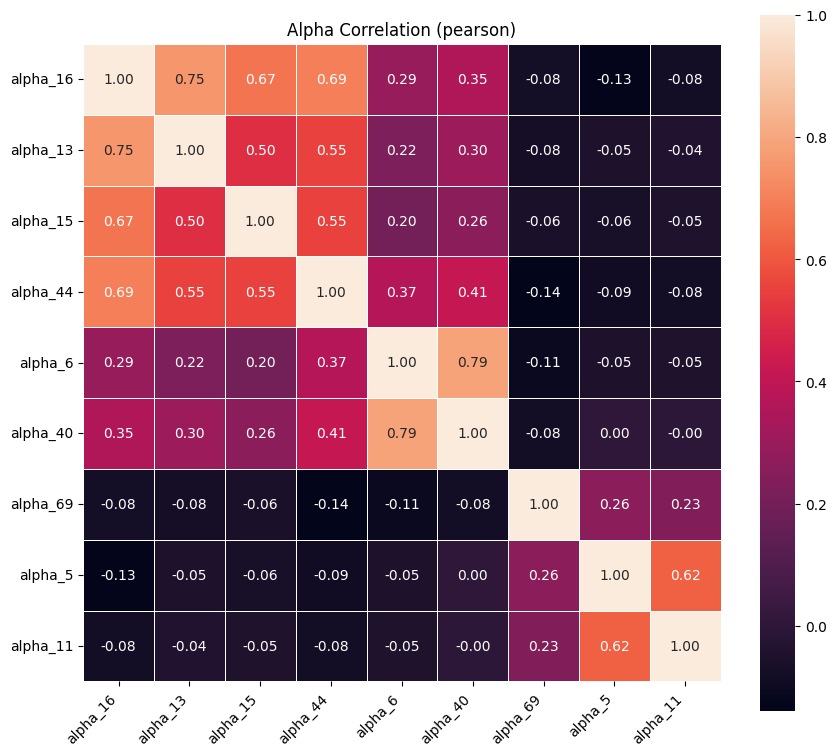

/tmp/ipython-input-396195933.py:319: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = df.stack(dropna=True)
/tmp/ipython-input-396195933.py:319: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = df.stack(dropna=True)
/tmp/ipython-input-396195933.py:319: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = df.stack(dropna=True)
/tmp/ipython-input-396195933.py:319: 

          alpha_16  alpha_13  alpha_15  alpha_44   alpha_6  alpha_40  alpha_69   alpha_5  alpha_11
alpha_16  1.000000  0.753908  0.669511  0.693836  0.288903  0.354693 -0.077475 -0.133056 -0.084327
alpha_13  0.753908  1.000000  0.499633  0.552997  0.221827  0.303051 -0.075260 -0.050889 -0.036994
alpha_15  0.669511  0.499633  1.000000  0.553570  0.197594  0.257629 -0.062721 -0.063672 -0.047572
alpha_44  0.693836  0.552997  0.553570  1.000000  0.369480  0.413211 -0.138456 -0.085918 -0.082110
alpha_6   0.288903  0.221827  0.197594  0.369480  1.000000  0.789748 -0.110383 -0.053888 -0.046799
alpha_40  0.354693  0.303051  0.257629  0.413211  0.789748  1.000000 -0.083464  0.003036 -0.002007
alpha_69 -0.077475 -0.075260 -0.062721 -0.138456 -0.110383 -0.083464  1.000000  0.257553  0.234905
alpha_5  -0.133056 -0.050889 -0.063672 -0.085918 -0.053888  0.003036  0.257553  1.000000  0.620054
alpha_11 -0.084327 -0.036994 -0.047572 -0.082110 -0.046799 -0.002007  0.234905  0.620054  1.000000


In [26]:

py_min = builtins.min
py_max = builtins.max
py_sum = builtins.sum

# === IC Info ===
def compute_ic_series(
        alpha_df: pd.DataFrame,
        logret_df: pd.DataFrame,
        sample_df: pd.DataFrame,
        method: str = "spearman"
) -> pd.Series:
    # align by tickers
    alpha_df, logret_df = alpha_df.align(logret_df, join='inner', axis=1)
    alpha_df, sample_df = alpha_df.align(sample_df, join='inner', axis=1)

    # r_{t+1}
    ret_next = logret_df.shift(-1)

    # common dates
    dates = alpha_df.index.intersection(ret_next.index).sort_values()

    ic_vals = []
    for dt in dates:
        mask = (sample_df.loc[dt] == 1)
        a = alpha_df.loc[dt, mask]
        r = ret_next.loc[dt, mask]

        valid = a.notna() & r.notna()
        if valid.sum() < 2:
            ic_vals.append(np.nan)
            continue

        if method.lower() == "spearman":
            ic = a[valid].corr(r[valid], method="spearman")
        elif method.lower() == "pearson":
            ic = a[valid].corr(r[valid], method="pearson")
        else:
            raise ValueError("method must be 'spearman' or 'pearson'")
        ic_vals.append(ic)

    return pd.Series(ic_vals, index=dates,
                     name="rank_ic" if method.lower()=="spearman" else "ic")


def compute_ic_all(
        alphas: dict[str, pd.DataFrame],
        logret_df: pd.DataFrame,
        sample_df: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    ic_mat      = {}
    rank_ic_mat = {}

    for nm, a_df in alphas.items():
        ic_mat[nm]      = compute_ic_series(a_df, logret_df, sample_df, "pearson")
        rank_ic_mat[nm] = compute_ic_series(a_df, logret_df, sample_df, "spearman")

    ic_df      = pd.DataFrame(ic_mat)
    rank_ic_df = pd.DataFrame(rank_ic_mat)

    summary = []
    for nm in alphas.keys():
        s_ic  = ic_df[nm].dropna()
        s_ric = rank_ic_df[nm].dropna()

        mean_ic,  std_ic  = s_ic.mean(),  s_ic.std(ddof=1)
        mean_ric, std_ric = s_ric.mean(), s_ric.std(ddof=1)

        summary.append({
            "alpha": nm,
            "mean_ic": mean_ic,
            "std_ic": std_ic,
            "ic_ir": np.nan if (std_ic == 0 or np.isnan(std_ic)) else mean_ic / std_ic,
            "mean_rank_ic": mean_ric,
            "std_rank_ic": std_ric,
            "rank_ic_ir": np.nan if (std_ric == 0 or np.isnan(std_ric)) else mean_ric / std_ric,
        })

    summary_df = (pd.DataFrame(summary)
                    .set_index("alpha")
                    .sort_values("mean_rank_ic", ascending=False))
    return ic_df, rank_ic_df, summary_df


# === Hypothesis Testing ===
def hac_se_vectorized(df: pd.DataFrame, maxlags: int = 5) -> pd.Series:
    """
    Newey–West style HAC standard error for the sample mean of each column in df.
    """
    X = df.to_numpy()
    T, K = X.shape
    n_obs = np.sum(~np.isnan(X), axis=0).astype(float)

    # effective max lag
    if np.all(np.isnan(n_obs)):
        return pd.Series(np.nan, index=df.columns)

    L = py_min(maxlags, int(np.nanmax(n_obs)) - 1)
    L = py_max(L, 0)

    mu = np.nanmean(X, axis=0)
    E  = X - mu

    gamma0 = np.nanmean(E * E, axis=0)

    sum_term = np.zeros(K)
    for l in range(1, L + 1):
        cov_l  = np.nanmean(E[l:] * E[:-l], axis=0)
        weight = 1 - l / (L + 1)
        n_eff  = np.maximum(n_obs - l, 1)
        sum_term += 2 * weight * cov_l * n_obs / n_eff

    var_mean = (gamma0 + sum_term) / n_obs
    var_mean = np.clip(var_mean, 0, None)
    return pd.Series(np.sqrt(var_mean), index=df.columns)


def alpha_significance(df: pd.DataFrame,
                       alpha_lv=[0.05],
                       null_h_pos=0.0,
                       null_h_neg=0.0,
                       ci_level=0.95,
                       acf_lags=5) -> pd.DataFrame:
    """
    Time-series hypothesis test on the mean of each column of df (IC or RankIC).

    For each alpha j:
      - Decide whether to use IID or HAC SE by checking ACF/PACF.
      - Perform a one-sided t-test in the direction of the sample mean.
      - Return n, mean, chosen se, t_stat, p_value, CI, and se_method.
    """

    # basic summary stats
    n_obs  = df.count()
    means  = df.mean()

    # IID standard error of the mean
    std_iid = df.std(ddof=1)
    se_iid  = std_iid / np.sqrt(n_obs)

    # HAC standard error of the mean
    se_hac = hac_se_vectorized(df, maxlags=acf_lags)

    # choose between IID and HAC per column using ACF/PACF
    se_final   = pd.Series(index=df.columns, dtype=float)
    method_map = pd.Series(index=df.columns, dtype=object)

    for col in df.columns:
        series = df[col].dropna()
        Tj = len(series)

        # too short or constant → fall back to IID
        if Tj < 3 or np.isclose(series.std(ddof=1), 0, equal_nan=True):
            se_final[col]   = se_iid[col]
            method_map[col] = "IID (short/constant)"
            continue

        nlags_j = py_min(acf_lags, (Tj // 2) - 1)
        nlags_j = py_max(1, nlags_j)

        if nlags_j < 1:
            se_final[col]   = se_iid[col]
            method_map[col] = "IID (lags<1)"
            continue

        try:
            # approximate 95% white-noise bound for acf/pacf under H0: no autocorrelation
            bound = 1.96 / np.sqrt(Tj)

            acfs  = acf(series, nlags=nlags_j, fft=False)
            pacfs = pacf(series, nlags=nlags_j)

            # acf/pacf[0] is lag 0; we check lags 1..nlags_j
            if np.any(np.abs(acfs[1:]) > bound) or np.any(np.abs(pacfs[1:]) > bound):
                se_final[col]   = se_hac[col]
                method_map[col] = f"HAC (nlags={nlags_j})"
            else:
                se_final[col]   = se_iid[col]
                method_map[col] = "IID"
        except Exception:
            # in case acf/pacf misbehaves numerically
            se_final[col]   = se_iid[col]
            method_map[col] = "IID (fallback)"

    # hypothesis test: one-sided in the direction of the mean
    sign = pd.Series(np.where(means >= 0, 1, -1), index=df.columns)
    nulls = pd.Series(
        np.where(sign > 0, null_h_pos, null_h_neg),
        index=df.columns
    )

    dfree = n_obs - 1
    t_stat = (means - nulls) / se_final

    # compute one-sided p-values
    t_stat_arr      = t_stat.values
    dfree_arr       = dfree.values
    right_tail_arr  = (sign > 0).values  # True → test mean > null

    p_val_arr = np.empty_like(t_stat_arr, dtype=float)
    pos_idx   = right_tail_arr
    neg_idx   = ~right_tail_arr

    # positive: P(T > t_stat)
    p_val_arr[pos_idx] = 1 - t.cdf(t_stat_arr[pos_idx], dfree_arr[pos_idx])
    # negative: P(T < t_stat)
    p_val_arr[neg_idx] = t.cdf(t_stat_arr[neg_idx], dfree_arr[neg_idx])

    p_val = pd.Series(p_val_arr, index=df.columns)

    # one-sided confidence bounds
    tcrit_arr    = t.ppf(ci_level, dfree_arr)
    tcrit        = pd.Series(tcrit_arr, index=df.columns)
    ci_lower     = pd.Series(np.nan, index=df.columns)
    ci_upper     = pd.Series(np.nan, index=df.columns)
    right_tail   = (sign > 0)

    ci_lower[right_tail]   = means[right_tail]   - tcrit[right_tail]   * se_final[right_tail]
    ci_upper[~right_tail]  = means[~right_tail]  + tcrit[~right_tail]  * se_final[~right_tail]

    out = pd.DataFrame({
        "n":        n_obs,
        "mean":     means,
        "se":       se_final,
        "t_stat":   t_stat,
        "p_value":  p_val,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper,
        "se_method": method_map,
    })

    for lev in alpha_lv:
        out[f"reject_by_p_{lev}"] = p_val < lev

    # keep same behavior as original: sort by t_stat descending
    return out.sort_values("t_stat", ascending=False)


def filter_df(df: pd.DataFrame) -> pd.DataFrame:
    same_direction = np.sign(df["mean_ic"]) == np.sign(df["mean_ric"])

    pos_mask = (
        (df["mean_ic"] >= 0) &
        (df["mean_ric"] >= 0) &
        (df["reject_by_p_0.05_ic"]) &
        (df["reject_by_p_0.05_ric"]) &
        (df["CI_lower_ic"]  > 0) &
        (df["CI_lower_ric"] > 0) &
        (df["mean_ic"]  > ic_thresh_pos) &
        (df["mean_ric"] > ric_thresh_pos)
    )

    neg_mask = (
        (df["mean_ic"] < 0) &
        (df["mean_ric"] < 0) &
        (df["reject_by_p_0.05_ic"]) &
        (df["reject_by_p_0.05_ric"]) &
        (df["CI_upper_ic"] < 0) &
        (df["CI_upper_ric"] < 0) &
        (df["mean_ic"]  < ic_thresh_neg) &
        (df["mean_ric"] < ric_thresh_neg)
    )

    return df[same_direction & (pos_mask | neg_mask)]


# Only d1 path (no d0)
def attach_orig_stats(row):
    om_ic  = orig_mean_ic_d1[row['alpha']]
    om_ric = orig_mean_ric_d1[row['alpha']]
    return pd.Series({
        'orig_mean_ic': om_ic,
        'abs_orig_mean_ic': np.abs(om_ic),
        'orig_mean_ric': om_ric,
        'abs_orig_mean_ric': np.abs(om_ric),
        'orig_sign_ic': np.sign(om_ic),
        'orig_sign_ric': np.sign(om_ric)
    })


def plot_alpha_corr_by_list(
    alpha_list: list[str],
    alpha_dict: dict[str, pd.DataFrame],
    corr_method: str = "pearson"
) -> None:
    names = alpha_list

    series_dict = {}
    for name in names:
        df = alpha_dict[name]
        s = df.stack(dropna=True)
        s.name = name
        series_dict[name] = s

    combined = pd.DataFrame(series_dict)
    corr = combined.corr(method=corr_method)

    w = py_max(6, len(names))
    h = py_max(6, len(names))
    plt.figure(figsize=(w, h))
    sns.heatmap(corr, annot=True, fmt=".2f", square=True,
                cbar_kws={"shrink": .8}, linewidths=0.5)
    plt.title(f"Alpha Correlation ({corr_method})")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def get_alpha_corr_matrix_by_list(
    alpha_list: list[str],
    alpha_dict: dict[str, pd.DataFrame],
    corr_method: str = "pearson"
) -> pd.DataFrame:
    names = alpha_list
    series_dict = {}
    for name in names:
        df = alpha_dict[name]
        s = df.stack(dropna=True)
        s.name = name
        series_dict[name] = s

    combined = pd.DataFrame(series_dict)
    return combined.corr(method=corr_method)


# ==========================
# === MAIN IC PIPELINE ===
# ==========================
ic_matrix, rank_ic_matrix, ic_summary = compute_ic_all(
    alphas = {
        "alpha_1":   alpha_1,  "alpha_2":   alpha_2,  "alpha_3":   alpha_3,  "alpha_4":   alpha_4,
        "alpha_5":   alpha_5,  "alpha_6":   alpha_6,  "alpha_7":   alpha_7,  "alpha_8":   alpha_8,
        "alpha_9":   alpha_9,  "alpha_10":  alpha_10, "alpha_11":  alpha_11, "alpha_12":  alpha_12,
        "alpha_13":  alpha_13, "alpha_14":  alpha_14, "alpha_15":  alpha_15, "alpha_16":  alpha_16,
        "alpha_17":  alpha_17, "alpha_18":  alpha_18, "alpha_19":  alpha_19, "alpha_20":  alpha_20,
        "alpha_21":  alpha_21, "alpha_22":  alpha_22, "alpha_23":  alpha_23, "alpha_24":  alpha_24,
        "alpha_25":  alpha_25, "alpha_26":  alpha_26, "alpha_27":  alpha_27, "alpha_28":  alpha_28,
        "alpha_29":  alpha_29, "alpha_30":  alpha_30, "alpha_31":  alpha_31, "alpha_32":  alpha_32,
        "alpha_33":  alpha_33, "alpha_34":  alpha_34, "alpha_35":  alpha_35, "alpha_36":  alpha_36,
        "alpha_37":  alpha_37, "alpha_38":  alpha_38, "alpha_39":  alpha_39, "alpha_40":  alpha_40,
        "alpha_41":  alpha_41, "alpha_43":  alpha_43, "alpha_44":  alpha_44, "alpha_45":  alpha_45,
        "alpha_46":  alpha_46, "alpha_47":  alpha_47, "alpha_49":  alpha_49, "alpha_50":  alpha_50,
        "alpha_51":  alpha_51, "alpha_52":  alpha_52, "alpha_55":  alpha_55, "alpha_57":  alpha_57,
        "alpha_58":  alpha_58, "alpha_59":  alpha_59, "alpha_60":  alpha_60, "alpha_61":  alpha_61,
        "alpha_62":  alpha_62, "alpha_63":  alpha_63, "alpha_64":  alpha_64, "alpha_65":  alpha_65,
        "alpha_66":  alpha_66, "alpha_67":  alpha_67, "alpha_68":  alpha_68, "alpha_69":  alpha_69,
        "alpha_70":  alpha_70, "alpha_71":  alpha_71, "alpha_72":  alpha_72, "alpha_73":  alpha_73,
        "alpha_74":  alpha_74, "alpha_75":  alpha_75, "alpha_76":  alpha_76, "alpha_77":  alpha_77,
        "alpha_78":  alpha_78, "alpha_79":  alpha_79, "alpha_80":  alpha_80, "alpha_81":  alpha_81,
        "alpha_82":  alpha_82, "alpha_83":  alpha_83, "alpha_84":  alpha_84, "alpha_85":  alpha_85,
        "alpha_86":  alpha_86, "alpha_87":  alpha_87, "alpha_88":  alpha_88, "alpha_89":  alpha_89,
        "alpha_90":  alpha_90, "alpha_91":  alpha_91, "alpha_92":  alpha_92, "alpha_93":  alpha_93,
        "alpha_94":  alpha_94, "alpha_95":  alpha_95, "alpha_96":  alpha_96, "alpha_97":  alpha_97,
        "alpha_98":  alpha_98, "alpha_99":  alpha_99, "alpha_100": alpha_100, "alpha_101": alpha_101,
    },
    logret_df = logret,
    sample_df = sample_space,  # binary 0/1 DataFrame
)

# 0. Original means (d1 only)
orig_mean_ic_d1  = ic_matrix.mean(axis=0)
orig_mean_ric_d1 = rank_ic_matrix.mean(axis=0)

# Tunable parameters
alpha_levels   = [0.05]
ci_level       = 0.95
pos_null_mean  = 0.0
neg_null_mean  = 0.0
ic_thresh_pos  = 0.001
ric_thresh_pos = 0.001
ic_thresh_neg  = -0.001
ric_thresh_neg = -0.001

# 2. Tests (with dynamic IID/HAC choice via ACF/PACF)
ic_hptest      = alpha_significance(ic_matrix,      alpha_levels, pos_null_mean, neg_null_mean, ci_level)
rank_ic_hptest = alpha_significance(rank_ic_matrix, alpha_levels, pos_null_mean, neg_null_mean, ci_level)

# 3. Merge and filter (d1 only)
d1 = ic_hptest.merge(rank_ic_hptest, left_index=True, right_index=True, suffixes=('_ic','_ric'))
d1_filtered = filter_df(d1).assign(delay='d1')

# 5. Combine -> final_alphas with original stats
final = d1_filtered.reset_index().rename(columns={'index':'alpha'})
final_alphas = pd.concat(
    [final[['alpha','delay']], final.apply(attach_orig_stats, axis=1), final.drop(columns=['alpha','delay'])],
    axis=1
)

print(final)

# 7. Output
pd.set_option('display.max_columns', None, 'display.width', 150, 'display.max_colwidth', None)
print(final_alphas.sort_values('abs_orig_mean_ic', ascending=False))
print(final_alphas)

# Build alpha_dict for selected alphas
names = final_alphas["alpha"].tolist()
alpha_dict = {name: globals()[name] for name in names}

# IC-based final factor set: |orig_mean_ic| >= 0.01
alpha_ic = final_alphas.set_index('alpha')['orig_mean_ic']
ic_floor = 0.01
sig_factors = [a for a in alpha_ic.index if abs(alpha_ic.loc[a]) >= ic_floor]

print(f"After IC-based filtering and |IC|>={ic_floor:.3f}, Alphas:", sig_factors)
print(alpha_ic.loc[sig_factors])

# Heatmap + correlation matrix for the final IC-selected factors
plot_alpha_corr_by_list(sig_factors, alpha_dict, corr_method="pearson")
corr_matrix = get_alpha_corr_matrix_by_list(sig_factors, alpha_dict, corr_method="pearson")
print(corr_matrix)


In [27]:
print(alpha_11.TSLA.loc[alpha_11.TSLA.notna()])
print(alpha_16.TSLA.loc[alpha_16.TSLA.notna()])


date
2023-11-06    0.056039
2023-11-07    0.000955
2023-11-08    0.000527
2023-11-09    0.000281
2023-11-10    0.058042
                ...   
2024-08-26    0.077387
2024-08-27    0.000394
2024-08-28    0.000233
2024-08-29    0.000327
2024-08-30    0.081795
Name: TSLA, Length: 170, dtype: float64
date
2023-11-06   -0.394203
2023-11-07   -0.395080
2023-11-08   -0.409185
2023-11-09   -0.403174
2023-11-10   -0.406706
                ...   
2024-08-26   -0.305678
2024-08-27   -0.316649
2024-08-28   -0.335264
2024-08-29   -0.351517
2024-08-30   -0.377210
Name: TSLA, Length: 162, dtype: float64


Loaded factor_dict with 9 factors.


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:164: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


== First 5 days NAV ==
 date
2024-09-03    1.000000e+08
2024-09-04    9.995175e+07
2024-09-05    1.017264e+08
2024-09-06    9.982831e+07
2024-09-09    1.016175e+08
Name: NAV, dtype: float64 

Mean Exec = 91.21%, Mean Util = 92.70%



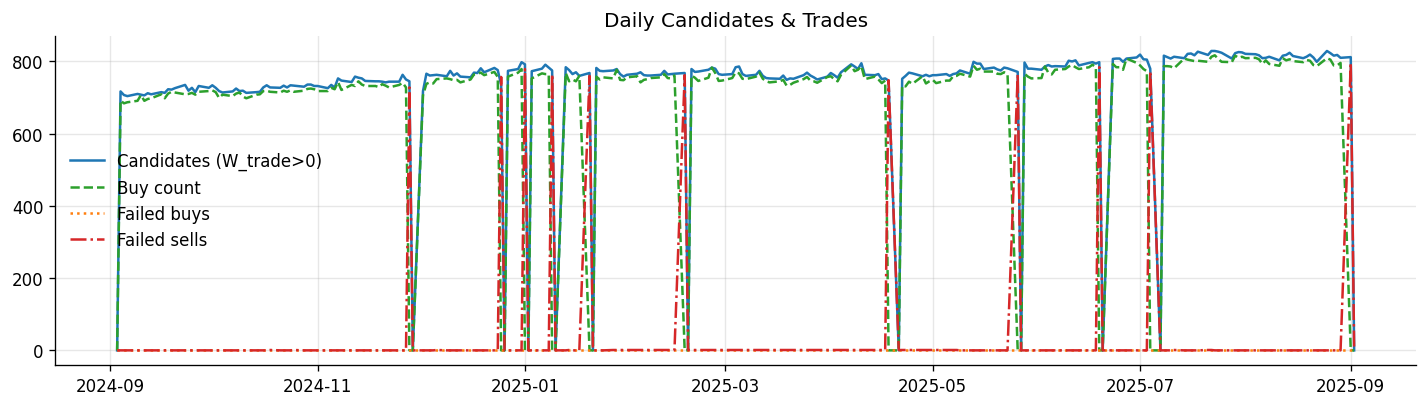

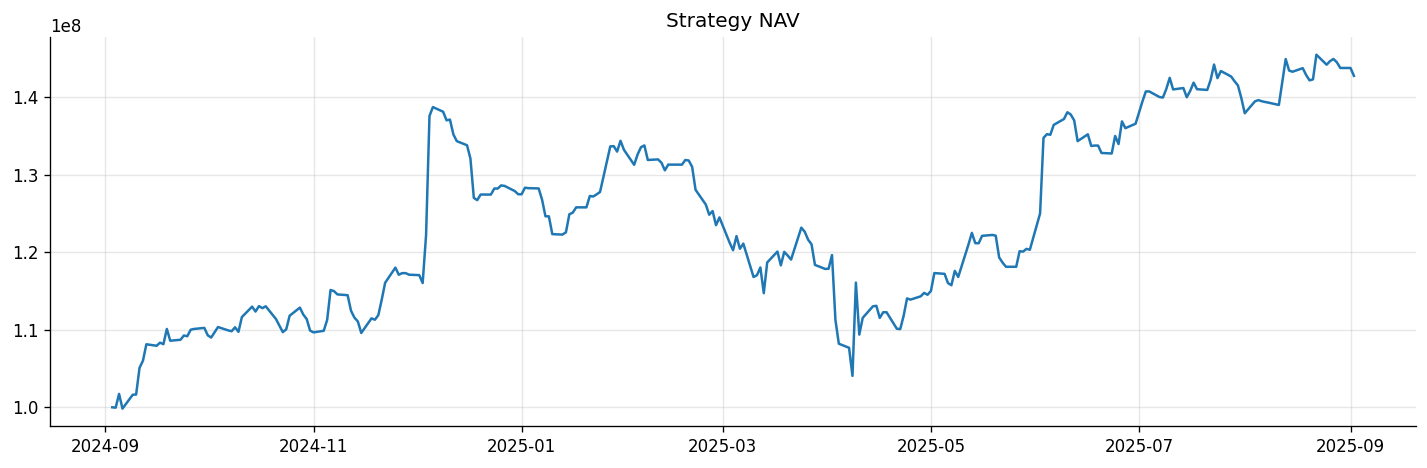

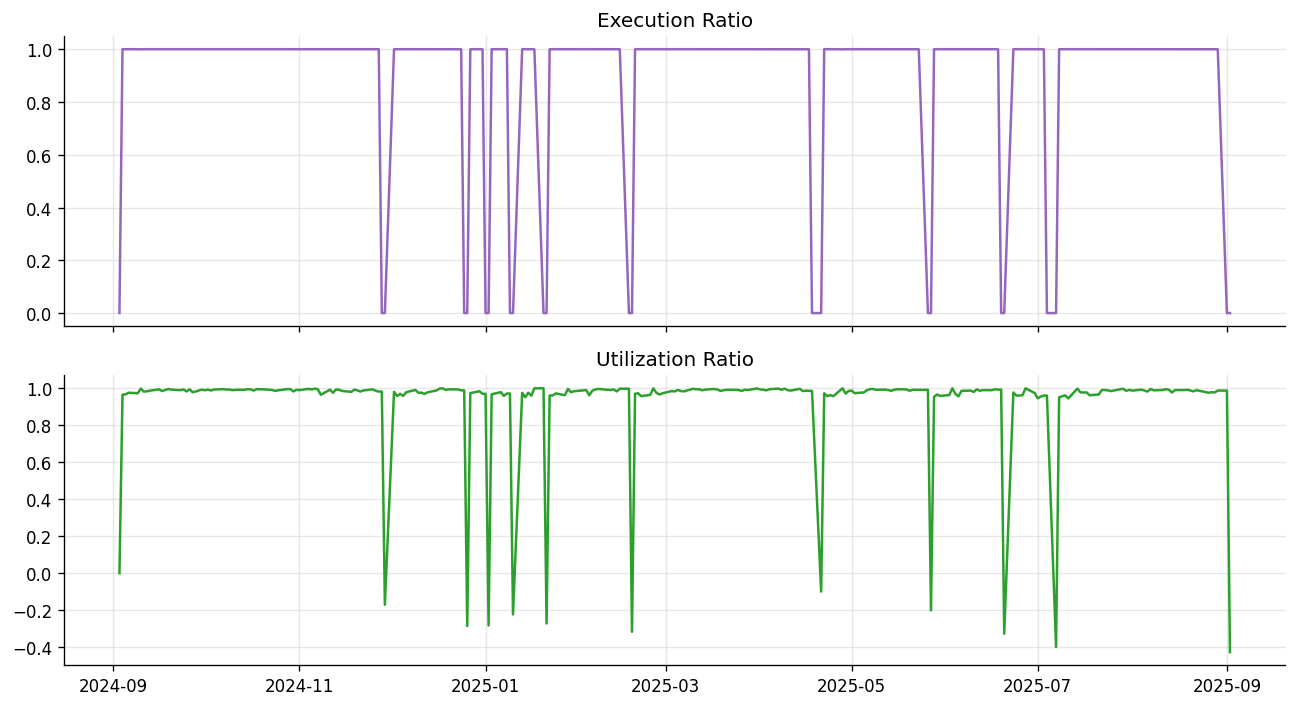

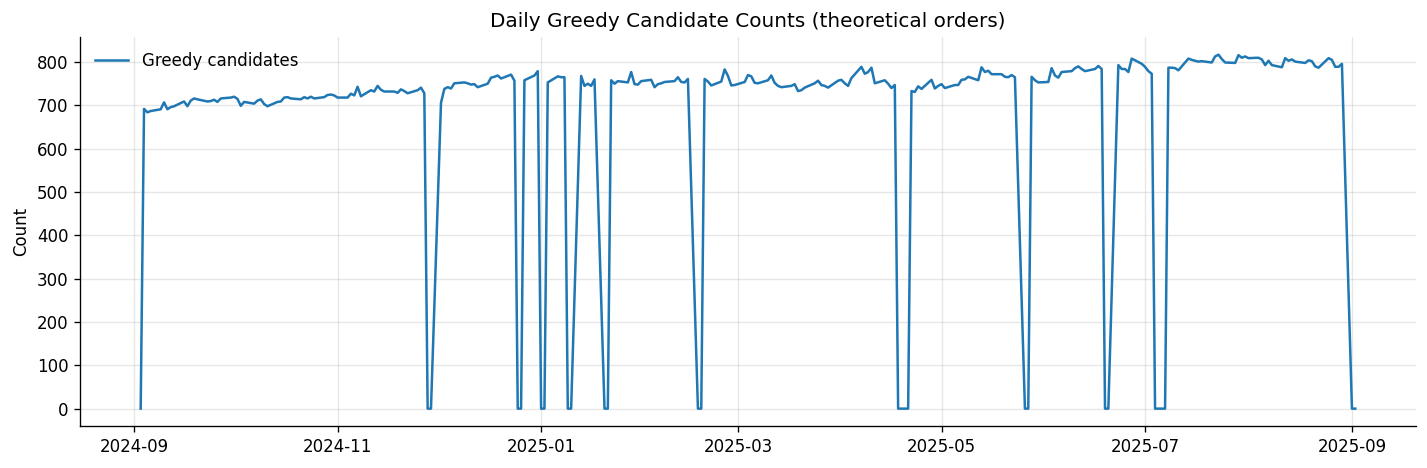

/tmp/ipython-input-3184188410.py:778: RuntimeWarning: invalid value encountered in divide
  ratio_day  = np.where(theory_tot > 0, exec_tot / theory_tot, np.nan)


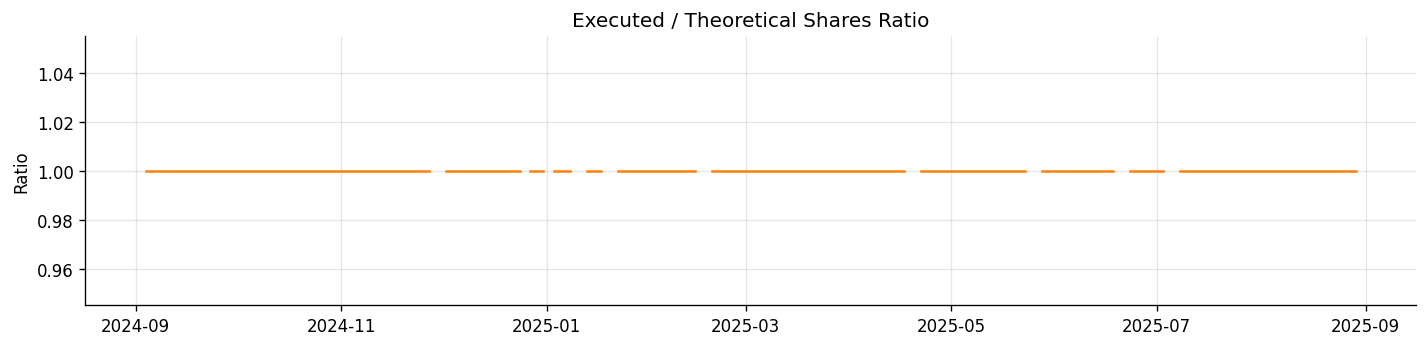

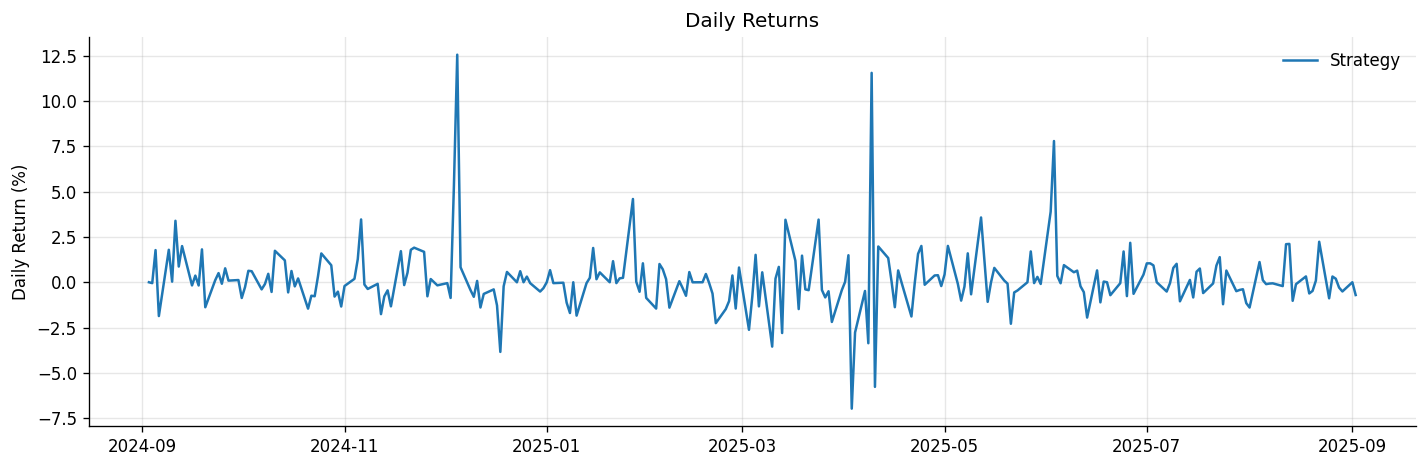

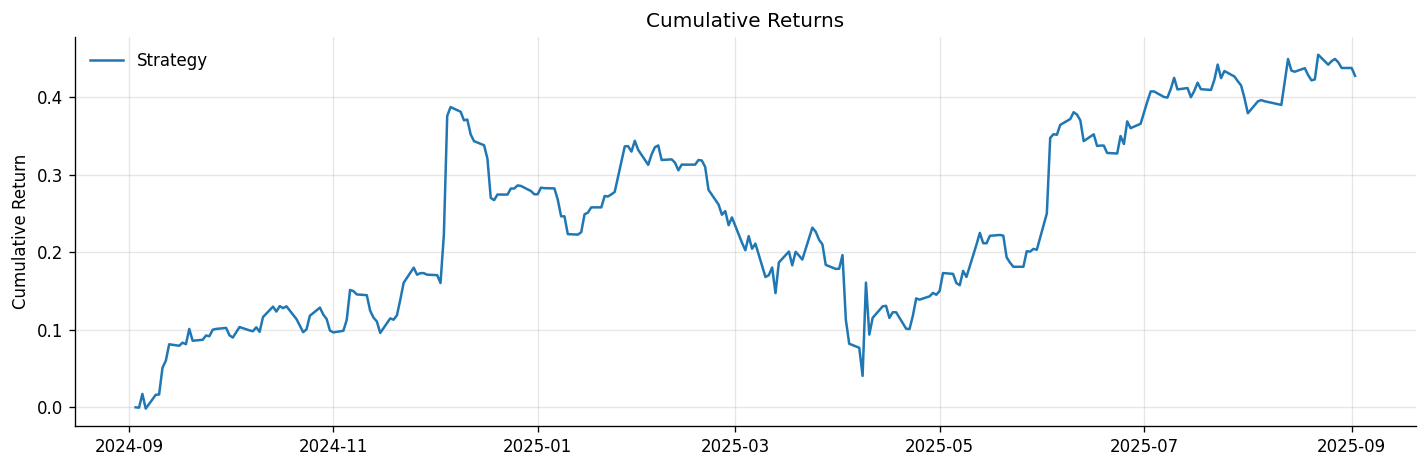

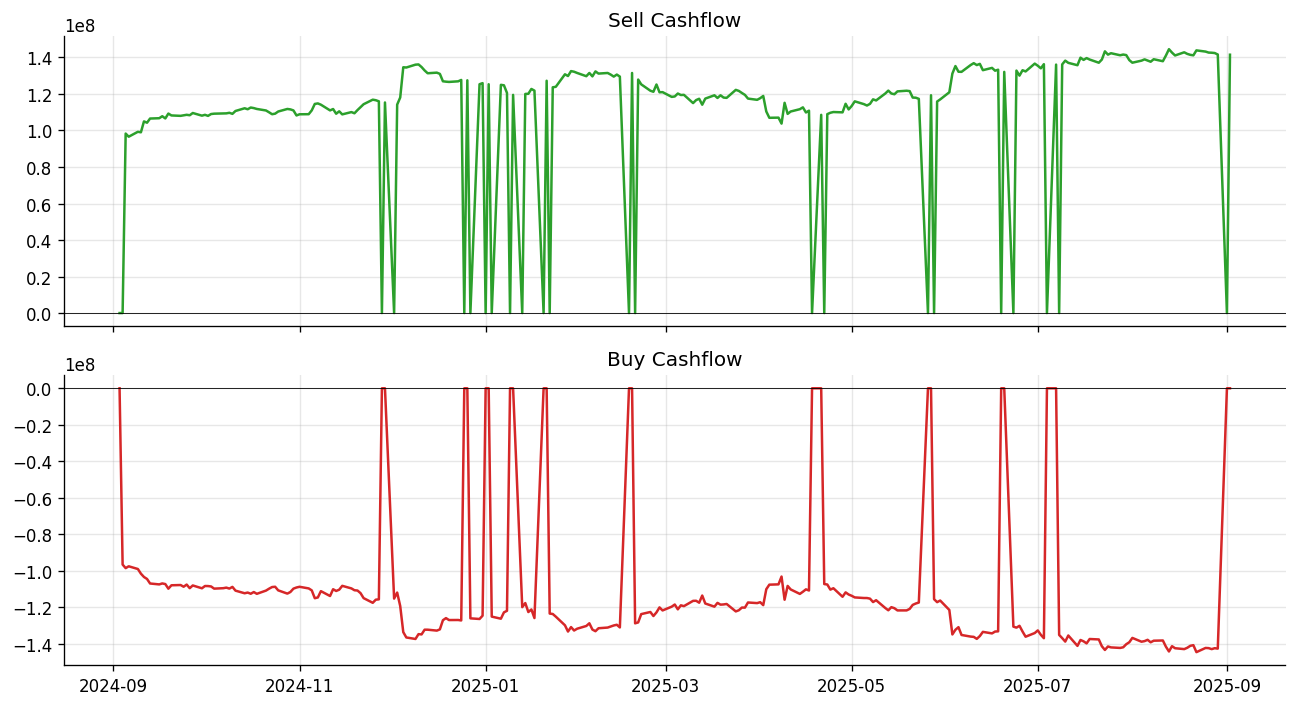

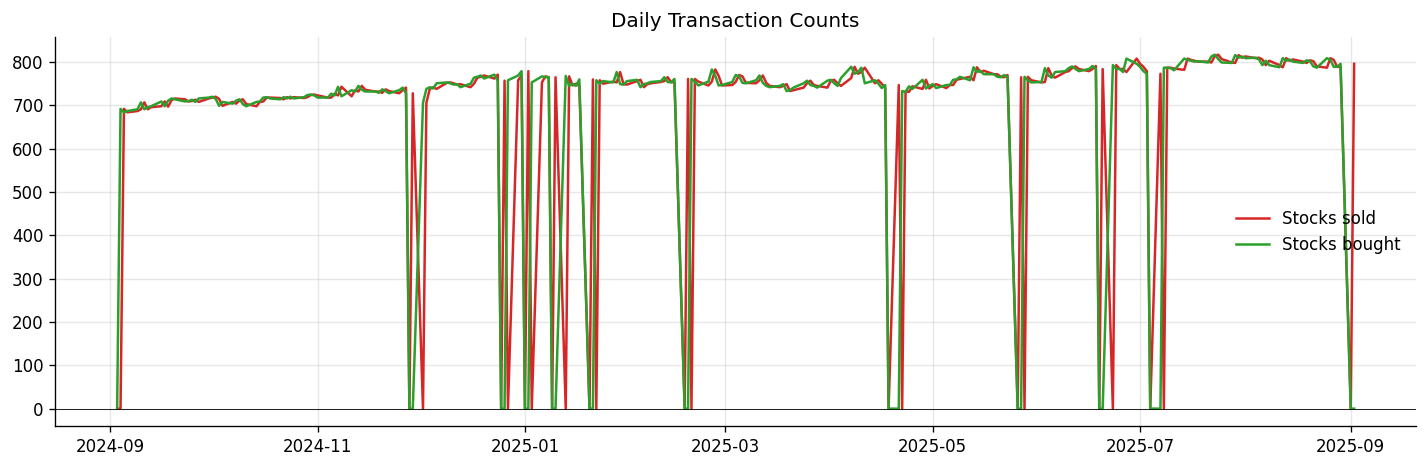

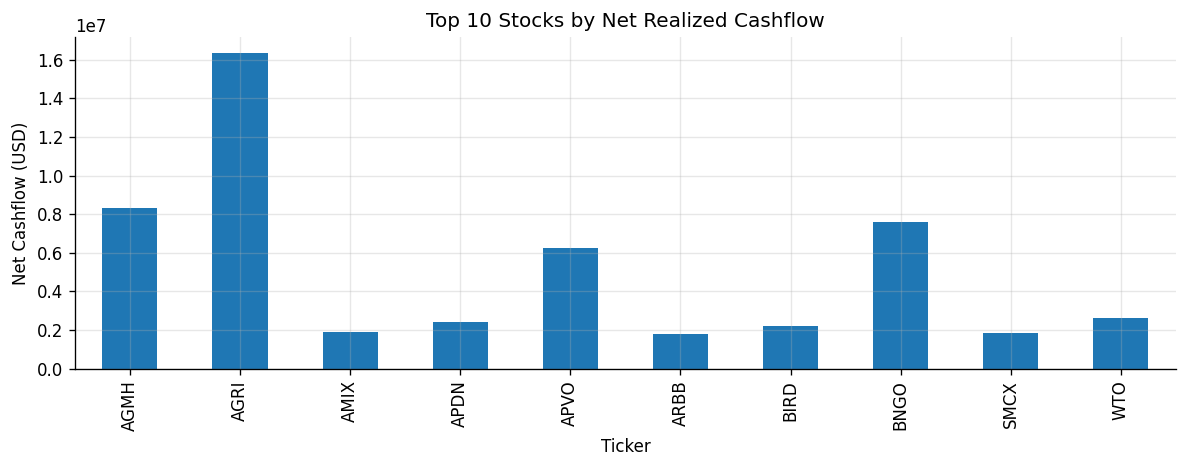

=== Backtest Report (Strategy) ===
Start NAV           : 100000000.00
End NAV             : 142749181.01
Total Return        : 42.75%
Annualized Return   : 42.89%
Annualized Vol      : 28.85%
Sharpe Ratio        : 1.49
Max Drawdown        : -24.99%

Backtest finished.
Available global report objects:
  plan_df             - daily theoretical positions
  exec_df             - executed trades (BUY/SELL)
  trade_top10_df      - top 10 realized cashflow stocks
  daily_softmax_df    - per-day scores & weights for all names
  top10_softmax_df    - daily top 10 by softmax weight
  bottom10_softmax_df - daily bottom 10 by softmax weight
  trades_df           - all trade cashflows (BUY/SELL)


In [34]:
# -------------------------------------------------------------------
# Matplotlib style: simple but presentation-friendly
# -------------------------------------------------------------------
plt.style.use("default")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["legend.frameon"] = False

# ============================================================
# 0. Global parameters for US softmax long-only strategy
# ============================================================

PARAMS_US = dict(
    tau_softmax      =1.4,    # τ in softmax: larger τ → more concentrated weights, tau in the formula
    top_pct          = 0.15,   # invest only in top X% names by composite score each day
    min_candidates   = 5,      # minimum number of names to invest in per day (if available)
    max_holding_days = 1,      # trading bars to hold after entry
    delay_days       = 0       # cooldown after selling before the stock can be bought again
)

# Trading constants (US market assumptions)
INIT_CASH = 1e8      # initial portfolio value in USD
LOT       = 1        # trade in single-share units
C_COMM    = 0.0001   # commission rate per side (1 bp)
C_IMP     = 0.0004   # impact / slippage per side (4 bps) → total ~5 bps
C_STAMP   = 0.0000   # stamp duty (0 for US cash equities)

# ============================================================
# 1. Factor loader: build_factor_dict (US, no d0 alphas)
# ============================================================

def build_factor_dict(
    alpha_names: list[str],
    start: str,
    end: str,
    dates: pd.Index | None = None
) -> dict[str, pd.DataFrame]:
    """
    Build a dict {factor_name: DataFrame(date x ticker)} for the given period.

    Convention:
      - For factor "alpha_13", there should be a loader function `load_alpha13`.
      - Loader takes the required global matrices (open, high, low, close,
        volume, etc.) as arguments.

    There are NO T+0 (d0) alphas in this US setup, so we only call `load_<base>`.

    No forward-fill or backward-fill is applied here:
      - If a factor has no value at (t, i), it stays NaN.
      - Later, if a stock has NaN factor(s), it simply gets weaker / neutral
        signals or is not selected by softmax.
    """
    out: dict[str, pd.DataFrame] = {}
    for name in alpha_names:
        base = name.replace("_", "")
        func_name = f"load_{base}"
        if func_name not in globals():
            raise NameError(f"Factor loading function {func_name} not found in globals().")
        func = globals()[func_name]

        # Inspect the function signature and feed global variables in order.
        sig = inspect.signature(func)
        args = []
        for p in sig.parameters.values():
            if p.name not in globals():
                raise NameError(f"{func_name} missing required global variable {p.name}")
            val = globals()[p.name]
            if isinstance(val, pd.DataFrame):
                args.append(val.loc[start:end])
            else:
                args.append(val)

        fac = func(*args).loc[start:end].copy()
        fac.index = pd.to_datetime(fac.index)

        if dates is not None:
            # Align on time axis; keep NaN where no factor is available.
            fac = fac.reindex(pd.to_datetime(dates))

        out[name] = fac

    return out

# ============================================================
# 2. Composite scores and softmax weights (US)
# ============================================================

def compute_composite_scores(
    dates: pd.Index,
    stocks: pd.Index,
    factor_dict: dict[str, pd.DataFrame],
    icir_map: dict[str, float],
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """
    Build composite score matrix S[t, i] from multiple alphas.

    For each factor f in factor_dict:
      1) Align factor values to [dates x stocks].
      2) Cross-sectional z-score per day:
             z_f(t, i) = (x_f(t, i) - mean_t) / std_t
         where std_t is the cross-sectional standard deviation at date t,
         computed only across non-NaN names.
         If there is no valid name on that date or std_t == 0,
         we set z_f(t, :) = 0 (factor contributes nothing that day).
      3) Multiply by that factor's IC-IR weight:
             S(t, i) += IC_IR_f * z_f(t, i)

    No forward-looking data is used:
    S[t, i] only depends on factor values at time t.
    """
    T = len(dates)
    N = len(stocks)
    S = np.zeros((T, N), dtype=np.float64)

    z_store: dict[str, np.ndarray] = {}

    for name, fac_df in factor_dict.items():
        if name not in icir_map:
            continue
        w_icir = icir_map.get(name, 0.0)
        if not np.isfinite(w_icir) or w_icir == 0.0:
            continue

        fac = fac_df.reindex(index=dates, columns=stocks)
        arr = fac.to_numpy(dtype=float)  # T x N

        z = np.empty_like(arr)
        for t in range(T):
            row = arr[t]
            mask = ~np.isnan(row)
            if not mask.any():
                z[t] = 0.0
                continue
            m = row[mask].mean()
            std = row[mask].std(ddof=1)
            if std == 0 or np.isnan(std):
                z[t] = 0.0
            else:
                z[t] = 0.0
                z[t, mask] = (row[mask] - m) / std

        z_store[name] = z
        S += w_icir * z

    return S, z_store


def _softmax_vec(v: np.ndarray, tau: float) -> np.ndarray:
    """
    Softmax: exp(τ * (v - max(v))) / sum_j exp(τ * (v_j - max(v))).

    τ > 0:
      - larger τ → more concentrated on high scores
      - smaller τ → closer to uniform weights.
    """
    v_safe = np.nan_to_num(v, nan=0.0)
    mx = np.max(v_safe)
    ex = np.exp(tau * (v_safe - mx))
    s = ex.sum()
    if s <= 0:
        return np.full_like(ex, 1.0 / len(ex))
    return ex / s


def build_softmax_weights_us(
    dates: pd.Index,
    stocks: pd.Index,
    S: np.ndarray,
    price_ok: np.ndarray,
    sample_day: np.ndarray,
    tau: float,
    top_pct: float,
    min_candidates: int = 1,
):
    """
    Given composite scores S[t, i], construct daily softmax weights W_signal[t, i]
    and detailed ranking information.

    For each date t:
      * Only consider names with:
            - price_ok[t, i] == 1  (valid close)
            - sample_day[t, i] == 1 (in trading universe)
            - S[t, i] is finite (no NaN / inf in composite score)
      * Sort those names by composite score S[t, i] descending.
      * Keep only the top k = max(int(n * top_pct), min_candidates).
      * Apply softmax with parameter τ on these k names; others get weight 0.

    Returns
    -------
    W_signal : np.ndarray, shape (T, N)
        Per-day target weights based on signals (before T+1 execution shift).
    daily_softmax_df : pd.DataFrame
        Full ranking per day: score and weight for every tradable name.
    top10_softmax_df : pd.DataFrame
        Per day, top 10 names by softmax weight.
    bottom10_softmax_df : pd.DataFrame
        Per day, bottom 10 names by softmax weight (among tradable names).
    """
    T, N = S.shape
    W_signal = np.zeros_like(S, dtype=np.float64)

    stk_arr = np.array(stocks)
    records: list[dict] = []
    top_frames = []
    bottom_frames = []

    for t in range(T):
        tradable_idx = []
        tradable_scores = []
        for i in range(N):
            if (
                price_ok[t, i] == 1
                and sample_day[t, i] == 1
                and np.isfinite(S[t, i])
            ):
                tradable_idx.append(i)
                tradable_scores.append(S[t, i])

        if len(tradable_idx) == 0:
            continue

        idx = np.array(tradable_idx, dtype=np.int64)
        scores = np.array(tradable_scores, dtype=np.float64)

        # sort by score descending
        order = np.argsort(-scores)
        idx_sorted = idx[order]

        n_all = len(idx_sorted)
        k = int(n_all * top_pct)
        if k < min_candidates:
            k = min_candidates
        if k > n_all:
            k = n_all

        chosen_idx = idx_sorted[:k]
        chosen_scores = S[t, chosen_idx].astype(np.float64, copy=False)
        w = _softmax_vec(chosen_scores, tau)
        W_signal[t, chosen_idx] = w

        # full per-day ranking, for reporting
        for rank, i in enumerate(idx_sorted):
            records.append(
                dict(
                    date=dates[t],
                    ticker=stk_arr[i],
                    rank=rank + 1,
                    score=float(S[t, i]),
                    weight=float(W_signal[t, i]),
                )
            )

        g = pd.DataFrame(
            {
                "date": dates[t],
                "ticker": stk_arr[idx_sorted],
                "score": S[t, idx_sorted],
                "weight": W_signal[t, idx_sorted],
            }
        )

        g_top = g.nlargest(10, columns="weight").copy()
        g_top["rank_in_day"] = np.arange(1, len(g_top) + 1)
        top_frames.append(g_top)

        g_bottom = g.nsmallest(10, columns="weight").copy()
        g_bottom["rank_in_day"] = np.arange(1, len(g_bottom) + 1)
        bottom_frames.append(g_bottom)

    daily_softmax_df = (
        pd.DataFrame.from_records(records)
        .set_index(["date", "ticker"])
        .sort_index()
    )

    if top_frames:
        top10_softmax_df = (
            pd.concat(top_frames, ignore_index=True)
            .set_index(["date", "ticker"])
            .sort_index()
        )
        bottom10_softmax_df = (
            pd.concat(bottom_frames, ignore_index=True)
            .set_index(["date", "ticker"])
            .sort_index()
        )
    else:
        top10_softmax_df = pd.DataFrame(columns=["score", "weight", "rank_in_day"])
        bottom10_softmax_df = pd.DataFrame(columns=["score", "weight", "rank_in_day"])

    return W_signal, daily_softmax_df, top10_softmax_df, bottom10_softmax_df

# ============================================================
# 3. Core backtest loop (US version, JIT-compiled, T+1 execution)
# ============================================================

@nb.njit(fastmath=True)
def _bt_loop_us(
    price: np.ndarray,
    W_trade: np.ndarray,
    price_ok: np.ndarray,
    sample_day: np.ndarray,
    max_holding_days: int,
    delay_days: int,
):
    """
    Core daily backtest loop for US softmax long-only strategy.

    Time convention
    ---------------
    * t = 0, 1, ..., T-1.
    * W_trade[t, i] is the target weight for stock i at the CLOSE of day t,
      already shifted by 1 day compared to the signal S:
          W_trade[t]   = W_signal[t-1],  t >= 1
          W_trade[0,:] = 0  (no trade on the first date)

    Trading logic (per day t)
    -------------------------
      0) Update last_valid_price for MTM (but not for trading decisions):
           if price_ok[t, i] == 1:
               last_valid_price[i] = price[t, i]

      1) SELL phase (always before BUY):
           - For any pos[i] > 0 with (t - entry_day[i]) >= max_holding_days,
             if price_ok[t, i] == 1, sell at close price[t, i].
             If price_ok[t, i] == 0 (no valid close), record a failed sell
             and keep the position; we will try again on the next date.

      2) If t is the last day (T-1): mark-to-market and stop (no new buys).
         NAV includes cash + market value of all still-open positions using
         last_valid_price.

      3) BUY phase:
           - With remaining cash, consider candidates where:
               W_trade[t, i] > 0,
               sample_day[t, i] == 1,
               price_ok[t, i] == 1,
               pos[i] == 0 (only open new positions),
               t >= next_trade_day[i] (respect cooldown after sell).
           - Sort candidates by W_trade[t, i] descending (greedy).
           - For each candidate:
                 target_dollar = cash_before * W_trade[t, i]
                 shares        = floor(target_dollar / price[t, i])
             Adjust for trading costs and available cash.

    NAV is always computed as:
        NAV_t = cash_t + sum_i pos[i] * last_valid_price[i]
    so there is no fake drop to ~0 when the close price is missing.
    """
    T, N = price.shape
    c_fee = C_COMM + C_IMP

    nav             = np.empty(T, dtype=np.float64)
    exec_arr        = np.zeros(T, dtype=np.float64)
    util_arr        = np.zeros(T, dtype=np.float64)
    sell_flow       = np.zeros(T, dtype=np.float64)
    buy_flow        = np.zeros(T, dtype=np.float64)
    sell_count      = np.zeros(T, dtype=np.int64)
    buy_count       = np.zeros(T, dtype=np.int64)
    fail_sell_count = np.zeros(T, dtype=np.int64)
    fail_buy_count  = np.zeros(T, dtype=np.int64)
    cum_pnl         = np.zeros(N, dtype=np.float64)  # gross exit cash
    theo_lot        = np.zeros((T, N), dtype=np.int64)
    exec_lot        = np.zeros((T, N), dtype=np.int64)
    sell_lot        = np.zeros((T, N), dtype=np.int64)

    cash            = INIT_CASH
    pos             = np.zeros(N, dtype=np.float64)  # number of shares
    entry_day       = -np.ones(N, dtype=np.int64)
    entry_price     = np.zeros(N, dtype=np.float64)
    next_trade_day  = np.zeros(N, dtype=np.int64)
    last_valid_price = np.zeros(N, dtype=np.float64)

    for t in range(T):
        # ------------------------------
        # 0) Update last valid prices for MTM
        # ------------------------------
        for i in range(N):
            if price_ok[t, i] == 1:
                last_valid_price[i] = price[t, i]

        # ------------------------------
        # 1) SELL phase
        # ------------------------------
        proceeds = 0.0
        sc = 0
        fs = 0

        for i in range(N):
            if pos[i] > 0.0:
                if (t - entry_day[i]) >= max_holding_days:
                    if price_ok[t, i] == 1:
                        p = price[t, i]
                        shares = pos[i]  # LOT = 1
                        val = shares * p * (1.0 - c_fee - C_STAMP)
                        proceeds   += val
                        cum_pnl[i] += val
                        pos[i]      = 0.0
                        entry_day[i]   = -1
                        entry_price[i] = 0.0
                        sc += 1
                        next_trade_day[i] = t + delay_days
                        sell_lot[t, i]    = int(shares)
                    else:
                        # no valid close → failed sell; keep position
                        fs += 1

        cash += proceeds
        sell_flow[t] = proceeds
        sell_count[t] = sc
        fail_sell_count[t] = fs

        # ------------------------------
        # 2) Last day: mark-to-market only
        # ------------------------------
        if t >= T - 1:
            nav_t = cash
            for i in range(N):
                if pos[i] > 0.0:
                    nav_t += pos[i] * last_valid_price[i]
            nav[t] = nav_t
            exec_arr[t] = 0.0
            util_arr[t] = (INIT_CASH - cash) / INIT_CASH
            continue

        # ------------------------------
        # 3) BUY phase
        # ------------------------------
        cash_before = cash
        cash_left = cash
        bc = 0
        fb = 0

        # If sample_day[t, :] is all zeros, there will simply be no trades
        order_i = np.empty(N, dtype=np.int64)
        order_w = np.empty(N, dtype=np.float64)
        cnt = 0

        for i in range(N):
            if (
                W_trade[t, i] > 0.0 and
                sample_day[t, i] == 1 and
                price_ok[t, i] == 1 and
                pos[i] == 0.0 and
                t >= next_trade_day[i]
            ):
                order_i[cnt] = i
                order_w[cnt] = W_trade[t, i]
                cnt += 1

        # sort candidates by weight descending (simple selection sort)
        for a in range(cnt):
            mx = a
            for b in range(a + 1, cnt):
                if order_w[b] > order_w[mx]:
                    mx = b
            if mx != a:
                tmp_i = order_i[a]
                order_i[a] = order_i[mx]
                order_i[mx] = tmp_i

                tmp_w = order_w[a]
                order_w[a] = order_w[mx]
                order_w[mx] = tmp_w

        total_target_w = 0.0
        for k in range(cnt):
            if order_w[k] > 0.0:
                total_target_w += order_w[k]

        if cnt == 0 or total_target_w <= 0.0:
            buy_flow[t] = 0.0
            buy_count[t] = 0
            fail_buy_count[t] = 0
            exec_arr[t] = 0.0
            util_arr[t] = (INIT_CASH - cash_left) / INIT_CASH

            nav_t = cash_left
            for i in range(N):
                if pos[i] > 0.0:
                    nav_t += pos[i] * last_valid_price[i]
            nav[t] = nav_t
            cash = cash_left
            continue

        # execute buys
        for k in range(cnt):
            i = order_i[k]
            p = price[t, i]

            target_dollar = cash_before * order_w[k]
            shares = int(math.floor(target_dollar / (p * LOT)))
            theo_lot[t, i] = shares

            if shares <= 0 or cash_left < p * LOT:
                fb += 1
                continue

            cost = shares * LOT * p * (1.0 + c_fee)
            if cost > cash_left:
                shares = int(math.floor(cash_left / (p * LOT * (1.0 + c_fee))))
                theo_lot[t, i] = shares
                cost = shares * LOT * p * (1.0 + c_fee)
                if shares <= 0:
                    fb += 1
                    continue

            cash_left      -= cost
            pos[i]         += shares * LOT
            entry_day[i]    = t
            entry_price[i]  = p
            exec_lot[t, i]  = shares
            bc += 1

        buy_flow[t] = -(cash_before - cash_left)
        buy_count[t] = bc
        fail_buy_count[t] = fb

        bought_today = cash_before - cash_left
        if total_target_w > 0.0 and cash_before > 0.0:
            # execution ratio relative to intended notional (per-day measure)
            exec_arr[t] = bought_today / (cash_before * total_target_w)
        else:
            exec_arr[t] = 0.0

        util_arr[t] = (INIT_CASH - cash_left) / INIT_CASH

        nav_t = cash_left
        for i in range(N):
            if pos[i] > 0.0:
                nav_t += pos[i] * last_valid_price[i]
        nav[t] = nav_t

        cash = cash_left

    return (
        nav, exec_arr, util_arr,
        sell_flow, buy_flow, sell_count, buy_count,
        fail_sell_count, fail_buy_count,
        cum_pnl, theo_lot, exec_lot, sell_lot
    )

# ============================================================
# 4. High-level backtest wrapper
# ============================================================

def run_backtest_softmax_us(
    close_df: pd.DataFrame,
    sample_df: pd.DataFrame,
    factor_dict: dict[str, pd.DataFrame],
    icir_map: dict[str, float],
    start: str,
    end: str,
    index_series: pd.Series | None = None,
    params: dict | None = None,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    """
    High-level US backtest wrapper.

    Steps:
      1) Slice price & sample to [start:end], align calendars, convert to datetime index.
         No forward-fill or backward-fill is applied to trading data.
      2) Compute composite scores S(t, i) from factor_dict and icir_map.
      3) Build softmax weights W_signal[t, i] and per-day ranking reports.
      4) Shift weights by 1 day to get W_trade (T+1 execution).
      5) Run Numba trading loop.
      6) Compute NAV, returns, performance statistics, and plots.
    """
    if params is None:
        params = PARAMS_US
    else:
        merged = PARAMS_US.copy()
        merged.update(params)
        params = merged

    # 1) data preparation (NO ffill / bfill for prices; missing values stay NaN)
    seg_c = close_df.loc[start:end].copy()
    seg_c.index = pd.to_datetime(seg_c.index)
    seg_c = seg_c.sort_index()
    seg_c = seg_c.astype(float)
    dates = seg_c.index
    stocks = seg_c.columns
    T, N = len(dates), len(stocks)

    seg_s = sample_df.loc[start:end].copy()
    seg_s.index = pd.to_datetime(seg_s.index)
    seg_s = seg_s.sort_index()
    seg_s = seg_s.reindex(dates)
    seg_s = seg_s.fillna(0.0)      # missing universe flag = not tradable
    sample_day = (seg_s.to_numpy() > 0).astype(np.uint8)

    price = seg_c.to_numpy(dtype=np.float64)
    price_ok = (~np.isnan(price)).astype(np.uint8)

    # 2) composite scores S[t, i]
    S, _ = compute_composite_scores(dates, stocks, factor_dict, icir_map)

    # 3) softmax weights and ranking dataframes (signal day)
    W_signal, daily_softmax_df, top10_softmax_df, bottom10_softmax_df = (
        build_softmax_weights_us(
            dates=dates,
            stocks=stocks,
            S=S,
            price_ok=price_ok,
            sample_day=sample_day,
            tau=params["tau_softmax"],
            top_pct=params["top_pct"],
            min_candidates=params["min_candidates"],
        )
    )

    # 4) T+1 execution: signal(t) -> trade(t+1)
    W_trade = np.zeros_like(W_signal)
    if T > 1:
        W_trade[1:, :] = W_signal[:-1, :]
        W_trade[0, :] = 0.0

    # 5) main backtest loop
    (
        nav, ex_arr, ut_arr,
        sell_flow, buy_flow, sell_cnt, buy_cnt,
        fail_sell_cnt, fail_buy_cnt,
        cum_pnl, theo_lot, exec_lot, sell_lot
    ) = _bt_loop_us(
        price=price,
        W_trade=W_trade,
        price_ok=price_ok,
        sample_day=sample_day,
        max_holding_days=params["max_holding_days"],
        delay_days=params["delay_days"],
    )

    # 6) strategy plan dataframe
    plan_records = []
    for t in range(T):
        for j in range(N):
            if W_trade[t, j] > 0.0:
                plan_records.append(
                    dict(
                        date=dates[t],
                        ticker=stocks[j],
                        in_universe=bool(sample_day[t, j]),
                        target_weight=W_trade[t, j],
                        theoretical_shares=theo_lot[t, j],
                    )
                )
    plan_df = (
        pd.DataFrame.from_records(plan_records)
        .set_index(["date", "ticker"])
        .sort_index()
    )

    # 7) executed trades dataframe
    exec_records = []
    for t in range(T):
        for j in range(N):
            if exec_lot[t, j] > 0:
                exec_records.append(
                    dict(
                        date=dates[t],
                        ticker=stocks[j],
                        executed_shares=exec_lot[t, j],
                        price=price[t, j],
                        side="BUY",
                    )
                )
            if sell_lot[t, j] > 0:
                exec_records.append(
                    dict(
                        date=dates[t],
                        ticker=stocks[j],
                        executed_shares=sell_lot[t, j],
                        price=price[t, j],
                        side="SELL",
                    )
                )
    exec_df = (
        pd.DataFrame.from_records(exec_records)
        .set_index(["date", "ticker"])
        .sort_index()
    )

    # 8) trade log & top 10 net PnL names (based on cashflows)
    trade_records = []
    for t in range(T):
        dt = dates[t]
        for j in range(N):
            bl = exec_lot[t, j]
            if bl > 0:
                pr = price[t, j]
                cf = -bl * LOT * pr * (1.0 + C_COMM + C_IMP)
                trade_records.append([stocks[j], dt, "BUY", bl, pr, cf])
            sl = sell_lot[t, j]
            if sl > 0:
                pr = price[t, j]
                cf = sl * LOT * pr * (1.0 - (C_COMM + C_IMP) - C_STAMP)
                trade_records.append([stocks[j], dt, "SELL", sl, pr, cf])

    if trade_records:
        trades_df = pd.DataFrame(
            trade_records,
            columns=["ticker", "date", "action", "shares", "price", "cash_flow"],
        ).set_index(["ticker", "date"]).sort_index()

        net_pnl = trades_df.groupby(level="ticker")["cash_flow"].sum()
        top10 = net_pnl.sort_values(ascending=False).head(10)
        trade_top10_df = trades_df.loc[top10.index]
    else:
        trades_df = pd.DataFrame(
            columns=["ticker", "date", "action", "shares", "price", "cash_flow"]
        ).set_index(["ticker", "date"])
        trade_top10_df = trades_df.copy()

    # expose useful dfs globally
    globals().update(
        {
            "plan_df": plan_df,
            "exec_df": exec_df,
            "trade_top10_df": trade_top10_df,
            "daily_softmax_df": daily_softmax_df,
            "top10_softmax_df": top10_softmax_df,
            "bottom10_softmax_df": bottom10_softmax_df,
            "trades_df": trades_df,
        }
    )

    # 9) assemble results & performance report
    nav_s  = pd.Series(nav, index=dates, name="NAV")
    exec_s = pd.Series(ex_arr, index=dates, name="Exec Rate")
    util_s = pd.Series(ut_arr, index=dates, name="Util Rate")
    strat_ret = nav_s.pct_change().fillna(0.0)

    print("== First 5 days NAV ==\n", nav_s.head(), "\n")
    print(f"Mean Exec = {exec_s.mean():.2%}, Mean Util = {util_s.mean():.2%}\n")

    # -------------------- plots: candidates & trades --------------------
    plt.figure(figsize=(12, 3.5))
    plt.plot(dates, (W_trade > 0).sum(axis=1), label="Candidates (W_trade>0)", color="tab:blue")
    plt.plot(dates, buy_cnt, label="Buy count", color="tab:green", linestyle="--")
    plt.plot(dates, fail_buy_cnt, label="Failed buys", color="tab:orange", linestyle=":")
    plt.plot(dates, fail_sell_cnt, label="Failed sells", color="tab:red", linestyle="-.")
    plt.title("Daily Candidates & Trades")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------- NAV curve --------------------
    plt.figure(figsize=(12, 4))
    plt.plot(dates, nav_s, color="tab:blue")
    plt.title("Strategy NAV")
    plt.tight_layout()
    plt.show()

    # -------------------- Exec / Util --------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    ax1.plot(dates, exec_s, color="tab:purple")
    ax1.set_title("Execution Ratio")
    ax2.plot(dates, util_s, color="tab:green")
    ax2.set_title("Utilization Ratio")
    plt.tight_layout()
    plt.show()

    # -------------------- daily greedy candidate counts --------------------
    plt.figure(figsize=(12, 4))
    plt.plot(dates, (theo_lot > 0).sum(axis=1), label="Greedy candidates", color="tab:blue")
    plt.title("Daily Greedy Candidate Counts (theoretical orders)")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------- executed / theoretical shares ratio --------------------
    theory_tot = theo_lot.sum(axis=1)
    exec_tot   = exec_lot.sum(axis=1)
    ratio_day  = np.where(theory_tot > 0, exec_tot / theory_tot, np.nan)
    plt.figure(figsize=(12, 3))
    plt.plot(dates, ratio_day, color="tab:orange")
    plt.title("Executed / Theoretical Shares Ratio")
    plt.ylabel("Ratio")
    plt.tight_layout()
    plt.show()

    # -------------------- daily & cumulative returns vs benchmark --------------------
    if index_series is not None:
        idx_ser = index_series.loc[start:end].copy()
        idx_ser.index = pd.to_datetime(idx_ser.index)
        idx_ser = idx_ser.sort_index()

        common_dates = dates.intersection(idx_ser.index)
        idx_ser = idx_ser.loc[common_dates]
        idx_ret = idx_ser.pct_change().fillna(0.0)

        strat_ret_aligned = strat_ret.loc[common_dates]
        net_ret = strat_ret_aligned - idx_ret
    else:
        idx_ser = None
        idx_ret = None
        net_ret = None
        common_dates = dates

    plt.figure(figsize=(12, 4))
    plt.plot(dates, strat_ret * 100, label="Strategy", color="tab:blue")
    if idx_ret is not None:
        plt.plot(common_dates, idx_ret * 100, label="Index", color="tab:gray")
        plt.plot(common_dates, net_ret * 100, label="Hedged", color="tab:orange", linestyle="--")
    plt.ylabel("Daily Return (%)")
    plt.title("Daily Returns")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(dates, (1 + strat_ret).cumprod() - 1, label="Strategy", color="tab:blue")
    if idx_ret is not None:
        plt.plot(common_dates, (1 + idx_ret).cumprod() - 1, label="Index", color="tab:gray")
        plt.plot(common_dates, (1 + net_ret).cumprod() - 1, label="Hedged", color="tab:orange", linestyle="--")
    plt.ylabel("Cumulative Return")
    plt.title("Cumulative Returns")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------- cashflows & trade counts --------------------
    sf_s = pd.Series(sell_flow, index=dates, name="Sell cashflow")
    bf_s = pd.Series(buy_flow, index=dates, name="Buy cashflow")
    fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    ax3.plot(dates, sf_s, color="tab:green")
    ax3.axhline(0, linewidth=0.5, color="black")
    ax3.set_title("Sell Cashflow")
    ax4.plot(dates, bf_s, color="tab:red")
    ax4.axhline(0, linewidth=0.5, color="black")
    ax4.set_title("Buy Cashflow")
    plt.tight_layout()
    plt.show()

    sc_s = pd.Series(sell_cnt, index=dates, name="Sell count")
    bc_s = pd.Series(buy_cnt, index=dates, name="Buy count")
    plt.figure(figsize=(12, 4))
    plt.plot(dates, sc_s, label="Stocks sold", color="tab:red")
    plt.plot(dates, bc_s, label="Stocks bought", color="tab:green")
    plt.axhline(0, color="black", linewidth=0.5)
    plt.legend()
    plt.title("Daily Transaction Counts")
    plt.tight_layout()
    plt.show()

    # -------------------- top 10 realized cashflow bar chart --------------------
    if not trade_top10_df.empty:
        plt.figure(figsize=(10, 4))
        trade_top10_df.groupby(level="ticker")["cash_flow"].sum().plot.bar(color="tab:blue")
        plt.title("Top 10 Stocks by Net Realized Cashflow")
        plt.ylabel("Net Cashflow (USD)")
        plt.xlabel("Ticker")
        plt.tight_layout()
        plt.show()

    # -------------------- performance report --------------------
    start_nv, end_nv = nav_s.iloc[0], nav_s.iloc[-1]
    total_rt = end_nv / start_nv - 1
    days = (dates[-1] - dates[0]).days
    years = days / 365.0 if days > 0 else 1.0
    ann_ret = (end_nv / start_nv) ** (1 / years) - 1 if years > 0 else np.nan
    ann_vol = strat_ret.std() * np.sqrt(len(strat_ret) / years) if years > 0 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dd = nav_s / nav_s.cummax() - 1

    print("=== Backtest Report (Strategy) ===")
    print(f"Start NAV           : {start_nv:.2f}")
    print(f"End NAV             : {end_nv:.2f}")
    print(f"Total Return        : {total_rt:.2%}")
    print(f"Annualized Return   : {ann_ret:.2%}")
    print(f"Annualized Vol      : {ann_vol:.2%}")
    print(f"Sharpe Ratio        : {sharpe:.2f}")
    print(f"Max Drawdown        : {dd.min():.2%}\n")

    if idx_ret is not None:
        idx_total_rt = idx_ser.iloc[-1] / idx_ser.iloc[0] - 1
        hedged_curve = (1 + net_ret).cumprod()
        hedged_total_rt = hedged_curve.iloc[-1] - 1
        hedged_ann_ret = hedged_curve.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
        hedged_ann_vol = net_ret.std() * np.sqrt(len(net_ret) / years) if years > 0 else np.nan
        hedged_sharpe = hedged_ann_ret / hedged_ann_vol if hedged_ann_vol > 0 else np.nan
        hedged_dd = hedged_curve / hedged_curve.cummax() - 1

        print("=== Benchmark & Hedged Metrics ===")
        print(f"Index Total Return    : {idx_total_rt:.2%}")
        print(f"Strategy Total Return : {total_rt:.2%}")
        print(f"Hedged Total Return   : {hedged_total_rt:.2%}")
        print(f"Average Daily Excess  : {net_ret.mean():.4%}\n")

        print("=== Hedged Annualized Metrics ===")
        print(f"Hedged Annualized Return : {hedged_ann_ret:.2%}")
        print(f"Hedged Annualized Vol    : {hedged_ann_vol:.2%}")
        print(f"Hedged Sharpe Ratio      : {hedged_sharpe:.2f}")
        print(f"Hedged Max Drawdown      : {hedged_dd.min():.2%}\n")

    return nav_s, exec_s, util_s

# ============================================================
# 5. Build inputs and run the backtest
# ============================================================

# Backtest date range
start_test = "2024-09-03"
end_test   = "2025-09-02"

# Optionally restrict the universe here:
# universe = [...]  # list of tickers you want to keep
# close_use = close[universe]
# sample_use = sample_space[universe]
# For now, use the full universe:
close_use = close
sample_use = sample_space

# 1) factor values
factor_dict = build_factor_dict(
    alpha_names = sig_factors,
    start       = start_test,
    end         = end_test,
    dates       = pd.to_datetime(close_use.loc[start_test:end_test].index),
)
print(f"Loaded factor_dict with {len(factor_dict)} factors.")

# 2) IC-IR map for each alpha
#    ic_summary should have index 'alpha' and column 'ic_ir'
icir_map = ic_summary["ic_ir"].to_dict()
icir_map = {k: v for k, v in icir_map.items() if k in factor_dict.keys()}

# 3) benchmark (e.g. SPY) - OPTIONAL, only for reporting (does NOT affect trading)
try:
    index_series = spy_close.loc[start_test:end_test].copy()
    index_series.index = pd.to_datetime(index_series.index)
    index_series = index_series.squeeze()
except NameError:
    index_series = None

# 4) run backtest
nav_s, exec_s, util_s = run_backtest_softmax_us(
    close_df     = close_use,
    sample_df    = sample_use,
    factor_dict  = factor_dict,
    icir_map     = icir_map,
    start        = start_test,
    end          = end_test,
    index_series = index_series,
)

print("Backtest finished.")
print("Available global report objects:")
print("  plan_df             - daily theoretical positions")
print("  exec_df             - executed trades (BUY/SELL)")
print("  trade_top10_df      - top 10 realized cashflow stocks")
print("  daily_softmax_df    - per-day scores & weights for all names")
print("  top10_softmax_df    - daily top 10 by softmax weight")
print("  bottom10_softmax_df - daily bottom 10 by softmax weight")
print("  trades_df           - all trade cashflows (BUY/SELL)")

In [35]:
print(trades_df)
print(trades_df.xs(pd.Timestamp("2025-06-23"), level="date")["cash_flow"].sum())


                  action  shares     price      cash_flow
ticker date                                              
A      2024-09-10    BUY    1043  138.0300 -144037.272645
       2024-09-11   SELL    1043  138.7000  144591.767950
       2024-10-15    BUY     174  144.5800  -25169.498460
       2024-10-16    BUY     818  139.1100 -113848.875990
       2024-10-16   SELL     174  139.1100   24193.037430
...                  ...     ...       ...            ...
ZYXI   2025-08-08    BUY   60421    1.4500  -87654.255225
       2025-08-08   SELL   40199    1.4500   58259.405725
       2025-08-11   SELL   60421    1.4200   85754.921090
ZZZ    2025-01-22    BUY    5731   28.3900 -162784.441545
       2025-01-23   SELL    5731   28.4317  162860.601664

[359486 rows x 4 columns]
-130540698.33660313


In [36]:
print("\n=== plan_df (first 20 rows) ===")
print(plan_df.head(20))

print("\n=== exec_df (first 20 rows) ===")
print(exec_df.head(20))

print("\n=== trade_top10_df (all rows) ===")
print(trade_top10_df)

print("\n=== daily_softmax_df (first 20 rows) ===")
print(daily_softmax_df.head(20))

print("\n=== top10_softmax_df (first 20 rows) ===")
print(top10_softmax_df.head(20))

print("\n=== bottom10_softmax_df (first 20 rows) ===")
print(bottom10_softmax_df.head(20))

print("\n=== trades_df (first 20 rows) ===")
print(trades_df.head(20))



=== plan_df (first 20 rows) ===
                   in_universe  target_weight  theoretical_shares
date       ticker                                                
2024-09-04 AA             True       0.001395                4575
           AAL            True       0.001395               13120
           AAOI           True       0.001395               10728
           AAON           True       0.001395                1568
           AAP            True       0.001395                3287
           AAPB           True       0.001395                5127
           AAPD           True       0.001395                7983
           AAPL           True       0.001395                 631
           AAPU           True       0.001395                4014
           AAT            True       0.001395                5223
           AAXJ           True       0.001395                1952
           AB             True       0.001395                4141
           ABAT           True       0.0013